# Laboratorio 1 — Series de Tiempo

El notebook sigue el orden de los ejercicios del enunciado: análisis
exploratorio, partición temporal, construcción de las siete series, análisis y
modelado de cada serie, y comparación final.

Las categorías complementarias seleccionadas son **Vías de ingreso** y
**Región dos**. Para las comparaciones regionales se usa
`Turista + Excursionista`, debido al quiebre metodológico documentado en 2023.


## 0. Configuración y funciones compartidas

Esta sección contiene únicamente configuración y funciones reutilizables. La
ejecución de cada análisis aparece posteriormente en el ejercicio que
corresponde.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd()
INPUT = ROOT / 'data' / 'data.xlsx'
OUT_BASE = ROOT / 'resultados_laboratorio_1'
OUT = OUT_BASE
FIG = OUT / 'figuras'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / nombre, bbox_inches='tight')

def fmt(valor):
    return f'{valor:,.0f}'


In [2]:
from __future__ import annotations

import logging
import math
import sys
import unicodedata
import warnings
from pathlib import Path

logging.getLogger("prophet.plot").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib

if "matplotlib.pyplot" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prophet import Prophet
from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller



VISITANTES = ("Turista", "Excursionista")
PANDEMIA_INICIO = pd.Timestamp("2020-03-01")
PANDEMIA_FIN = pd.Timestamp("2021-12-01")
CORTE_METODOLOGICO = pd.Timestamp("2023-01-01")
SEMILLA = 3084

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").disabled = True


In [3]:
def _slug(texto: str) -> str:
    normalizado = unicodedata.normalize("NFKD", str(texto))
    ascii_texto = normalizado.encode("ascii", "ignore").decode("ascii")
    return "_".join(ascii_texto.lower().split()).replace("/", "_")


def _guardar_modelo(fig: plt.Figure, nombre: str) -> None:
    FIG.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(FIG / nombre, bbox_inches="tight")
    plt.close(fig)


def _cargar_datos() -> pd.DataFrame:
    if not INPUT.exists():
        raise FileNotFoundError(f"No se encontró el archivo de entrada: {INPUT}")

    datos = pd.read_excel(INPUT, sheet_name="Datos")
    datos.columns = datos.columns.str.strip()
    requeridas = {
        "Año",
        "Mes cod",
        "País",
        "Región dos",
        "Tipo de Viajero",
        "Viajero",
    }
    faltantes = requeridas.difference(datos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas requeridas: {sorted(faltantes)}")

    datos["Año"] = pd.to_numeric(datos["Año"], errors="coerce")
    datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors="coerce")
    datos["Viajero"] = pd.to_numeric(datos["Viajero"], errors="coerce")
    datos["fecha"] = pd.to_datetime(
        {
            "year": datos["Año"],
            "month": datos["Mes cod"],
            "day": 1,
        },
        errors="coerce",
    )
    validos = (
        datos["fecha"].notna()
        & datos["Viajero"].notna()
        & datos["Viajero"].ge(0)
        & datos["Región dos"].notna()
    )
    return datos.loc[validos].drop_duplicates().copy()


def _crear_series(
    datos: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # El ranking usa la medida completa y todos los meses, no un año particular.
    ranking = (
        datos.assign(region_dos=datos["Región dos"].astype(str).str.strip())
        .loc[lambda x: ~x["region_dos"].isin({"", "0", "nan"})]
        .groupby("region_dos", observed=True)["Viajero"]
        .sum()
        .sort_values(ascending=False)
        .rename("viajeros_acumulados")
        .to_frame()
    )
    ranking["participacion"] = (
        ranking["viajeros_acumulados"] / ranking["viajeros_acumulados"].sum()
    )
    ranking["posicion"] = np.arange(1, len(ranking) + 1)
    top3 = ranking.head(3).copy()
    regiones = top3.index.tolist()

    indice = pd.date_range(
        datos["fecha"].min(), datos["fecha"].max(), freq="MS", name="fecha"
    )
    base_top3 = datos.loc[datos["Región dos"].isin(regiones)].copy()

    todas = (
        base_top3.groupby(["fecha", "Región dos"], observed=True)["Viajero"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=indice, columns=regiones, fill_value=0)
        .astype(float)
    )
    comparables = (
        base_top3.loc[base_top3["Tipo de Viajero"].isin(VISITANTES)]
        .groupby(["fecha", "Región dos"], observed=True)["Viajero"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=indice, columns=regiones, fill_value=0)
        .astype(float)
    )
    todas.index.name = comparables.index.name = "fecha"
    return top3, todas, comparables


def _eda(
    datos: pd.DataFrame,
    top3: pd.DataFrame,
    todas: pd.DataFrame,
    comparables: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    OUT.mkdir(parents=True, exist_ok=True)
    FIG.mkdir(parents=True, exist_ok=True)

    paises = (
        datos.groupby("País", observed=True)["Viajero"]
        .sum()
        .sort_values(ascending=False)
        .rename("viajeros_acumulados")
        .to_frame()
    )
    paises["participacion"] = paises["viajeros_acumulados"] / paises[
        "viajeros_acumulados"
    ].sum()

    tipo_anual = (
        datos.pivot_table(
            index="Año",
            columns="Tipo de Viajero",
            values="Viajero",
            aggfunc="sum",
            fill_value=0,
        )
        .sort_index()
        .astype(float)
    )

    top3.to_csv(OUT / "top3_region_dos.csv", encoding="utf-8-sig")
    todas.to_csv(
        OUT / "series_top3_todas_categorias.csv", encoding="utf-8-sig"
    )
    comparables.to_csv(
        OUT / "series_top3_turista_excursionista.csv", encoding="utf-8-sig"
    )
    paises.to_csv(OUT / "ranking_paises.csv", encoding="utf-8-sig")
    tipo_anual.to_csv(
        OUT / "composicion_tipo_viajero_anual.csv", encoding="utf-8-sig"
    )

    top_paises = paises.head(15).sort_values("viajeros_acumulados")
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(
        top_paises.index.astype(str),
        top_paises["viajeros_acumulados"],
        color="#4472C4",
    )
    ax.set(
        title="Quince países/mercados con mayor flujo acumulado (2009–junio 2026)",
        xlabel="Viajeros acumulados",
        ylabel="País o agrupación de mercado",
    )
    _guardar_modelo(fig, "08_top_paises.png")

    ranking_region = (
        datos.assign(region_dos=datos["Región dos"].astype(str).str.strip())
        .loc[lambda x: ~x["region_dos"].isin({"", "0", "nan"})]
        .groupby("region_dos", observed=True)["Viajero"]
        .sum()
        .sort_values()
    )
    colores = [
        "#D9E2F3" if nombre not in top3.index else "#4472C4"
        for nombre in ranking_region.index
    ]
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(ranking_region.index, ranking_region.values, color=colores)
    ax.set(
        title="Flujo acumulado por Región dos; Top 3 resaltado",
        xlabel="Viajeros acumulados",
        ylabel="Región dos",
    )
    _guardar_modelo(fig, "09_ranking_region_dos.png")

    fig, ax = plt.subplots(figsize=(13, 6))
    for region in comparables.columns:
        ax.plot(comparables.index, comparables[region], label=region, linewidth=1.5)
    ax.axvspan(
        PANDEMIA_INICIO,
        PANDEMIA_FIN,
        color="grey",
        alpha=0.15,
        label="Pandemia",
    )
    ax.axvline(
        CORTE_METODOLOGICO,
        color="#C00000",
        linestyle="--",
        linewidth=1,
        label="Cambio de fuente 2023",
    )
    ax.set(
        title="Visitantes mensuales (Turista + Excursionista) — Top 3 Región dos",
        xlabel="Fecha",
        ylabel="Visitantes",
    )
    ax.legend(ncol=2, fontsize=8)
    _guardar_modelo(fig, "10_series_top3_region_dos.png")

    columnas_tipo = [
        c
        for c in ["Turista", "Excursionista", "Viajero", "Cruceristas"]
        if c in tipo_anual.columns
    ]
    fig, ax = plt.subplots(figsize=(12, 6))
    tipo_anual[columnas_tipo].plot.area(ax=ax, alpha=0.82)
    ax.axvline(2023, color="#C00000", linestyle="--", linewidth=1)
    ax.set(
        title="Composición anual por tipo de viajero",
        xlabel="Año",
        ylabel="Personas",
    )
    ax.legend(title="Tipo", fontsize=8)
    _guardar_modelo(fig, "11_tipo_viajero_anual.png")

    return paises, tipo_anual


In [4]:
def _adf(serie: pd.Series) -> dict[str, float | int]:
    limpia = pd.Series(serie).replace([np.inf, -np.inf], np.nan).dropna()
    if limpia.nunique() < 2 or len(limpia) < 20:
        return {
            "adf_estadistico": np.nan,
            "p_valor": np.nan,
            "rezagos": np.nan,
            "observaciones": len(limpia),
        }
    resultado = adfuller(limpia, autolag="AIC")
    return {
        "adf_estadistico": float(resultado[0]),
        "p_valor": float(resultado[1]),
        "rezagos": int(resultado[2]),
        "observaciones": int(resultado[3]),
    }


def _diagnostico_series(
    series: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    resumen: list[dict[str, object]] = []
    estacionariedad: list[dict[str, object]] = []
    d_sugerido: dict[str, int] = {}

    for region in series.columns:
        serie = series[region].astype(float)
        log_serie = np.log1p(serie)
        transformaciones = {
            "nivel": serie,
            "log1p": log_serie,
            "primera_diferencia_log1p": log_serie.diff(),
            "diferencia_estacional_log1p": log_serie.diff(12),
            "diferencia_regular_y_estacional_log1p": log_serie.diff().diff(12),
        }
        pruebas: dict[str, dict[str, float | int]] = {}
        for nombre, transformada in transformaciones.items():
            prueba = _adf(transformada)
            pruebas[nombre] = prueba
            estacionariedad.append(
                {"region": region, "transformacion": nombre, **prueba}
            )

        p_log = float(pruebas["log1p"]["p_valor"])
        d = 0 if np.isfinite(p_log) and p_log < 0.05 else 1
        d_sugerido[region] = d
        mitad = len(serie) // 2
        var_1 = float(serie.iloc[:mitad].var())
        var_2 = float(serie.iloc[mitad:].var())
        razon_var = var_2 / var_1 if var_1 > 0 else np.nan
        resumen.append(
            {
                "region": region,
                "inicio": serie.index.min().strftime("%Y-%m"),
                "fin": serie.index.max().strftime("%Y-%m"),
                "frecuencia": "Mensual",
                "observaciones": len(serie),
                "media": serie.mean(),
                "desviacion_estandar": serie.std(),
                "coeficiente_variacion": serie.std() / serie.mean(),
                "acf_rezago_1": serie.autocorr(1),
                "acf_rezago_12": serie.autocorr(12),
                "razon_varianza_segunda_primera_mitad": razon_var,
                "transformacion_propuesta": (
                    "log1p: estabiliza la varianza, admite ceros y conserva "
                    "predicciones no negativas al invertirla"
                ),
                "d_sugerido_adf_log1p": d,
                "D_estacional_propuesto": 1,
                "p_q_a_comparar": "p∈{0,1,2}; q∈{0,1}; selección por AIC y RMSE",
            }
        )

        descomp = seasonal_decompose(
            log_serie, model="additive", period=12, extrapolate_trend="freq"
        )
        fig = descomp.plot()
        fig.set_size_inches(12, 8)
        fig.suptitle(
            f"Descomposición de log1p visitantes — {region}", y=1.02
        )
        _guardar_modelo(fig, f"12_descomposicion_{_slug(region)}.png")

        fig, axes = plt.subplots(2, 1, figsize=(11, 7))
        max_lags = min(48, len(log_serie) // 2 - 1)
        plot_acf(log_serie, lags=max_lags, zero=False, ax=axes[0])
        plot_pacf(log_serie, lags=max_lags, zero=False, method="ywm", ax=axes[1])
        axes[0].set_title(f"ACF de log1p visitantes — {region}")
        axes[1].set_title(f"PACF de log1p visitantes — {region}")
        _guardar_modelo(fig, f"13_acf_pacf_{_slug(region)}.png")

    resumen_df = pd.DataFrame(resumen)
    estacionariedad_df = pd.DataFrame(estacionariedad)
    resumen_df.to_csv(
        OUT / "resumen_diagnostico_series.csv",
        index=False,
        encoding="utf-8-sig",
    )
    estacionariedad_df.to_csv(
        OUT / "pruebas_adf_regiones.csv", index=False, encoding="utf-8-sig"
    )
    return resumen_df, estacionariedad_df, d_sugerido


def _impacto_pandemia(series: pd.DataFrame) -> pd.DataFrame:
    anual = series.resample("YS").sum()
    anual.index = anual.index.year
    filas: list[dict[str, object]] = []
    for region in series.columns:
        base_2019 = float(anual.loc[2019, region])
        posteriores = anual.loc[2020:2025, region]
        recuperacion = posteriores[posteriores >= base_2019]
        filas.append(
            {
                "region": region,
                "visitantes_2019": base_2019,
                "visitantes_2020": anual.loc[2020, region],
                "cambio_2019_2020": anual.loc[2020, region] / base_2019 - 1,
                "visitantes_2021": anual.loc[2021, region],
                "cambio_2019_2021": anual.loc[2021, region] / base_2019 - 1,
                "visitantes_2022": anual.loc[2022, region],
                "nivel_2022_vs_2019": anual.loc[2022, region] / base_2019,
                "visitantes_2025": anual.loc[2025, region],
                "nivel_2025_vs_2019": anual.loc[2025, region] / base_2019,
                "primer_año_recupera_2019": (
                    int(recuperacion.index[0]) if len(recuperacion) else np.nan
                ),
            }
        )
    impacto = pd.DataFrame(filas)
    impacto.to_csv(
        OUT / "impacto_pandemia_regiones.csv",
        index=False,
        encoding="utf-8-sig",
    )

    indice_2019 = anual.loc[2009:2025].div(anual.loc[2019]).mul(100)
    fig, ax = plt.subplots(figsize=(12, 6))
    for region in indice_2019.columns:
        ax.plot(
            indice_2019.index,
            indice_2019[region],
            marker="o",
            markersize=3,
            label=region,
        )
    ax.axhline(100, color="black", linestyle=":", linewidth=1)
    ax.axvspan(2020, 2021, color="grey", alpha=0.15)
    ax.set(
        title="Impacto y recuperación: visitantes anuales (2019 = 100)",
        xlabel="Año",
        ylabel="Índice (2019 = 100)",
    )
    ax.legend(fontsize=8)
    _guardar_modelo(fig, "14_impacto_pandemia_indice_2019.png")
    return impacto


def _metricas(real: pd.Series, pronostico: pd.Series) -> tuple[float, float]:
    y = np.asarray(real, dtype=float)
    yhat = np.asarray(pronostico, dtype=float)
    return (
        float(np.mean(np.abs(y - yhat))),
        float(np.sqrt(np.mean(np.square(y - yhat)))),
    )


def _diagnostico_residuos(residuos: pd.Series) -> dict[str, float]:
    resid = (
        pd.Series(residuos)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )
    if len(resid) < 15:
        return {
            "media_residuos": np.nan,
            "desviacion_residuos": np.nan,
            "ljung_box_p_12": np.nan,
            "jarque_bera_p": np.nan,
        }
    lag = min(12, max(1, len(resid) // 5))
    lb = acorr_ljungbox(resid, lags=[lag], return_df=True)
    jb = jarque_bera(resid)
    return {
        "media_residuos": float(resid.mean()),
        "desviacion_residuos": float(resid.std()),
        "ljung_box_p_12": float(lb["lb_pvalue"].iloc[-1]),
        "jarque_bera_p": float(jb.pvalue),
    }


In [5]:
def _candidatos_arima(d: int) -> list[tuple[tuple[int, int, int], tuple[int, int, int, int]]]:
    alterno = 1 - d
    candidatos = [
        ((1, d, 1), (0, 0, 0, 0)),
        ((0, d, 1), (0, 1, 1, 12)),
        ((1, d, 1), (0, 1, 1, 12)),
        ((2, d, 0), (1, 1, 0, 12)),
        ((1, alterno, 1), (1, 1, 1, 12)),
    ]
    # Conserva el orden y elimina configuraciones duplicadas.
    return list(dict.fromkeys(candidatos))


def _nombre_arima(
    orden: tuple[int, int, int],
    estacional: tuple[int, int, int, int],
) -> str:
    if estacional == (0, 0, 0, 0):
        return f"ARIMA{orden}"
    return f"SARIMA{orden}x{estacional}"


def _ajustar_arimas(
    train: pd.Series,
    test: pd.Series,
    d: int,
) -> tuple[pd.DataFrame, dict[str, object]]:
    y_log = np.log1p(train)
    filas: list[dict[str, object]] = []
    modelos: dict[str, object] = {}

    for orden, estacional in _candidatos_arima(d):
        nombre = _nombre_arima(orden, estacional)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ajuste = SARIMAX(
                    y_log,
                    order=orden,
                    seasonal_order=estacional,
                    trend="c" if orden[1] == 0 and estacional[1] == 0 else None,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=250)
            pronostico = pd.Series(
                np.expm1(
                    np.asarray(
                        ajuste.get_forecast(steps=len(test)).predicted_mean,
                        dtype=float,
                    )
                ),
                index=test.index,
            ).clip(lower=0)
            mae, rmse = _metricas(test, pronostico)
            convergio = bool(ajuste.mle_retvals.get("converged", True))
            filas.append(
                {
                    "modelo_arima": nombre,
                    "p": orden[0],
                    "d": orden[1],
                    "q": orden[2],
                    "P": estacional[0],
                    "D": estacional[1],
                    "Q": estacional[2],
                    "s": estacional[3],
                    "AIC": ajuste.aic,
                    "BIC": ajuste.bic,
                    "MAE_prueba": mae,
                    "RMSE_prueba": rmse,
                    "convergio": convergio,
                    "estado": "ok",
                }
            )
            modelos[nombre] = (ajuste, pronostico)
        except Exception as exc:  # deja evidencia del candidato fallido
            filas.append(
                {
                    "modelo_arima": nombre,
                    "p": orden[0],
                    "d": orden[1],
                    "q": orden[2],
                    "P": estacional[0],
                    "D": estacional[1],
                    "Q": estacional[2],
                    "s": estacional[3],
                    "AIC": np.nan,
                    "BIC": np.nan,
                    "MAE_prueba": np.nan,
                    "RMSE_prueba": np.nan,
                    "convergio": False,
                    "estado": f"error: {type(exc).__name__}: {exc}",
                }
            )

    tabla = pd.DataFrame(filas)
    validos = tabla.loc[
        tabla["estado"].eq("ok") & np.isfinite(tabla["AIC"])
    ].copy()
    if validos.empty:
        raise RuntimeError("Ningún candidato ARIMA/SARIMA pudo ajustarse")
    # La consigna pide seleccionar con métricas de prueba. AIC/BIC se conservan
    # como diagnóstico dentro de la misma escala, pero no se privilegia un AIC
    # menor si produce una trayectoria explosiva fuera de muestra.
    elegido = validos.sort_values(["RMSE_prueba", "MAE_prueba", "AIC"]).iloc[0][
        "modelo_arima"
    ]
    ajuste, pronostico = modelos[str(elegido)]
    # Los residuos del ARIMA pertenecen a la escala log1p del ajuste. Se evita
    # invertir los estados difusos iniciales, que puede crear residuos numéricos
    # enormes sin significado sustantivo.
    residuos = pd.Series(
        np.asarray(ajuste.resid, dtype=float), index=train.index
    ).iloc[24:]
    return tabla, {
        "nombre": str(elegido),
        "ajuste": ajuste,
        "pronostico": pronostico,
        "residuos": residuos,
        "AIC": float(ajuste.aic),
        "BIC": float(ajuste.bic),
        "escala_ic": "log1p",
        "escala_residuos": "log1p",
    }


def _ajustar_otros_modelos(
    train: pd.Series, test: pd.Series
) -> dict[str, dict[str, object]]:
    modelos: dict[str, dict[str, object]] = {}

    # Seasonal naïve.
    meses = np.arange(len(test)) % 12
    patron = train.iloc[-12:].to_numpy(dtype=float)
    pred_naive = pd.Series(patron[meses], index=test.index).clip(lower=0)
    modelos["Seasonal naïve"] = {
        "pronostico": pred_naive,
        "residuos": (train - train.shift(12)).dropna(),
        "AIC": np.nan,
        "BIC": np.nan,
        "escala_ic": "no aplica",
        "escala_residuos": "original",
    }

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ses = SimpleExpSmoothing(
            train, initialization_method="estimated"
        ).fit(optimized=True)
    modelos["Suavizamiento exponencial simple"] = {
        "pronostico": pd.Series(
            np.asarray(ses.forecast(len(test)), dtype=float), index=test.index
        ).clip(lower=0),
        "residuos": pd.Series(
            np.asarray(ses.resid, dtype=float), index=train.index
        ),
        "AIC": float(ses.aic),
        "BIC": float(ses.bic),
        "escala_ic": "original",
        "escala_residuos": "original",
    }

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        hw = ExponentialSmoothing(
            train,
            trend="add",
            damped_trend=True,
            seasonal="add",
            seasonal_periods=12,
            initialization_method="estimated",
        ).fit(optimized=True, use_brute=True)
    modelos["Holt-Winters"] = {
        "pronostico": pd.Series(
            np.asarray(hw.forecast(len(test)), dtype=float), index=test.index
        ).clip(lower=0),
        "residuos": pd.Series(
            np.asarray(hw.resid, dtype=float), index=train.index
        ),
        "AIC": float(hw.aic),
        "BIC": float(hw.bic),
        "escala_ic": "original",
        "escala_residuos": "original",
    }

    prophet_train = pd.DataFrame({"ds": train.index, "y": train.values})
    prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.10,
        uncertainty_samples=0,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prophet.fit(prophet_train)
    pred_test = prophet.predict(pd.DataFrame({"ds": test.index}))
    pred_train = prophet.predict(pd.DataFrame({"ds": train.index}))
    modelos["Prophet"] = {
        "pronostico": pd.Series(
            pred_test["yhat"].to_numpy(dtype=float), index=test.index
        ).clip(lower=0),
        "residuos": train
        - pd.Series(pred_train["yhat"].to_numpy(dtype=float), index=train.index),
        "AIC": np.nan,
        "BIC": np.nan,
        "escala_ic": "no disponible",
        "escala_residuos": "original",
    }
    return modelos


def _evaluar_modelos(
    series: pd.DataFrame,
    d_sugerido: dict[str, int],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    comparacion: list[dict[str, object]] = []
    candidatos: list[pd.DataFrame] = []
    predicciones: list[pd.DataFrame] = []
    residuos_elegidos: list[pd.DataFrame] = []

    for region in series.columns:
        serie = series[region].astype(float)
        n_train = math.floor(0.70 * len(serie))
        train, test = serie.iloc[:n_train], serie.iloc[n_train:]
        tabla_arima, arima = _ajustar_arimas(
            train, test, d_sugerido[region]
        )
        tabla_arima.insert(0, "region", region)
        candidatos.append(tabla_arima)

        modelos = {
            "ARIMA/SARIMA seleccionado": arima,
            **_ajustar_otros_modelos(train, test),
        }
        pred_region = pd.DataFrame(
            {"fecha": test.index, "region": region, "real": test.values}
        )
        resid_map: dict[str, pd.Series] = {}
        for nombre, info in modelos.items():
            pred = pd.Series(info["pronostico"], index=test.index).clip(lower=0)
            if pred.isna().any() or len(pred) != len(test):
                raise ValueError(f"Pronóstico inválido para {region} / {nombre}")
            mae, rmse = _metricas(test, pred)
            diag = _diagnostico_residuos(pd.Series(info["residuos"]))
            comparacion.append(
                {
                    "region": region,
                    "modelo": nombre,
                    "inicio_train": train.index.min().strftime("%Y-%m"),
                    "fin_train": train.index.max().strftime("%Y-%m"),
                    "inicio_prueba": test.index.min().strftime("%Y-%m"),
                    "fin_prueba": test.index.max().strftime("%Y-%m"),
                    "n_train": len(train),
                    "n_prueba": len(test),
                    "MAE": mae,
                    "RMSE": rmse,
                    "AIC": info["AIC"],
                    "BIC": info["BIC"],
                    "escala_AIC_BIC": info["escala_ic"],
                    "configuracion": info.get("nombre", ""),
                    "escala_residuos": info["escala_residuos"],
                    **diag,
                }
            )
            pred_region[nombre] = pred.values
            resid_map[nombre] = pd.Series(info["residuos"]).dropna()

        resultados_region = pd.DataFrame(
            [r for r in comparacion if r["region"] == region]
        )
        candidatos_validos = resultados_region.loc[
            resultados_region["ljung_box_p_12"].ge(0.05)
        ]
        if candidatos_validos.empty:
            candidatos_validos = resultados_region
        mejor = str(
            candidatos_validos.sort_values(["RMSE", "MAE"]).iloc[0]["modelo"]
        )
        resid_mejor = resid_map[mejor]
        residuos_elegidos.append(
            pd.DataFrame(
                {
                    "region": region,
                    "modelo": mejor,
                    "residuo": resid_mejor.to_numpy(dtype=float),
                }
            )
        )
        predicciones.append(pred_region)

        fig, ax = plt.subplots(figsize=(13, 6))
        ax.plot(train.index, train, color="#808080", linewidth=1, label="Train")
        ax.plot(
            test.index,
            test,
            color="black",
            linewidth=2,
            label="Real (prueba)",
        )
        paleta = sns.color_palette("tab10", n_colors=len(modelos))
        for color, (nombre, info) in zip(paleta, modelos.items()):
            ax.plot(
                test.index,
                info["pronostico"],
                linewidth=1.2,
                color=color,
                label=nombre,
            )
        ax.axvline(test.index.min(), color="#C00000", linestyle="--", linewidth=1)
        ax.set(
            title=f"Pronósticos 70/30 — {region}",
            xlabel="Fecha",
            ylabel="Visitantes",
        )
        ax.legend(fontsize=7, ncol=2)
        _guardar_modelo(fig, f"15_pronosticos_{_slug(region)}.png")

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].plot(np.arange(len(resid_mejor)), resid_mejor.values)
        axes[0].axhline(0, color="black", linewidth=1)
        axes[0].set(title="Residuos en el tiempo", xlabel="Observación")
        plot_acf(
            resid_mejor,
            lags=min(36, len(resid_mejor) // 2 - 1),
            zero=False,
            ax=axes[1],
        )
        axes[1].set_title("ACF de residuos")
        axes[2].hist(resid_mejor, bins=20, color="#4472C4", alpha=0.85)
        axes[2].set(title="Distribución de residuos", xlabel="Residuo")
        fig.suptitle(f"Diagnóstico del mejor modelo — {region}: {mejor}", y=1.03)
        _guardar_modelo(fig, f"16_residuos_mejor_{_slug(region)}.png")

    comparacion_df = pd.DataFrame(comparacion)
    comparacion_df["mejor_por_rmse"] = False
    indices_mejor = comparacion_df.groupby("region")["RMSE"].idxmin()
    comparacion_df.loc[indices_mejor, "mejor_por_rmse"] = True
    comparacion_df["seleccion_final"] = False
    for region, grupo in comparacion_df.groupby("region"):
        validos = grupo.loc[grupo["ljung_box_p_12"].ge(0.05)]
        if validos.empty:
            validos = grupo
        indice = validos.sort_values(["RMSE", "MAE"]).index[0]
        comparacion_df.loc[indice, "seleccion_final"] = True
    candidatos_df = pd.concat(candidatos, ignore_index=True)
    predicciones_df = pd.concat(predicciones, ignore_index=True)
    residuos_df = pd.concat(residuos_elegidos, ignore_index=True)

    comparacion_df.to_csv(
        OUT / "comparacion_modelos_regiones.csv",
        index=False,
        encoding="utf-8-sig",
    )
    candidatos_df.to_csv(
        OUT / "comparacion_candidatos_arima.csv",
        index=False,
        encoding="utf-8-sig",
    )
    predicciones_df.to_csv(
        OUT / "predicciones_prueba_regiones.csv",
        index=False,
        encoding="utf-8-sig",
    )
    residuos_df.to_csv(
        OUT / "residuos_mejores_modelos.csv",
        index=False,
        encoding="utf-8-sig",
    )

    orden_modelos = (
        comparacion_df.groupby("modelo")["RMSE"].mean().sort_values().index
    )
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(
        data=comparacion_df,
        x="RMSE",
        y="region",
        hue="modelo",
        hue_order=orden_modelos,
        ax=ax,
    )
    ax.set(
        title="RMSE fuera de muestra por región y modelo",
        xlabel="RMSE (menor es mejor)",
        ylabel="Región dos",
    )
    ax.legend(title="Modelo", fontsize=7, loc="best")
    _guardar_modelo(fig, "17_comparacion_rmse_modelos.png")
    return comparacion_df, candidatos_df, predicciones_df, residuos_df


In [6]:
def _fuerza_componentes(series: pd.DataFrame) -> pd.DataFrame:
    filas: list[dict[str, object]] = []
    for region in series.columns:
        serie = series[region].astype(float)
        log_serie = np.log1p(serie)
        dec = seasonal_decompose(
            log_serie, model="additive", period=12, extrapolate_trend="freq"
        )
        resid = dec.resid.dropna()
        estacional = dec.seasonal.reindex(resid.index)
        tendencia = dec.trend.reindex(resid.index)
        fuerza_estacional = max(
            0.0,
            1.0
            - float(np.var(resid))
            / float(np.var(resid + estacional)),
        )
        fuerza_tendencia = max(
            0.0,
            1.0
            - float(np.var(resid))
            / float(np.var(resid + tendencia)),
        )
        filas.append(
            {
                "region": region,
                "fuerza_estacional": min(1.0, fuerza_estacional),
                "fuerza_tendencia": min(1.0, fuerza_tendencia),
                "mes_pico_promedio": int(serie.groupby(serie.index.month).mean().idxmax()),
                "mes_valle_promedio": int(
                    serie.groupby(serie.index.month).mean().idxmin()
                ),
            }
        )
    resultado = pd.DataFrame(filas)
    resultado.to_csv(
        OUT / "comparacion_componentes_regiones.csv",
        index=False,
        encoding="utf-8-sig",
    )
    return resultado


def _informe(
    datos: pd.DataFrame,
    top3: pd.DataFrame,
    resumen: pd.DataFrame,
    estacionariedad: pd.DataFrame,
    impacto: pd.DataFrame,
    modelos: pd.DataFrame,
    componentes: pd.DataFrame,
) -> str:
    mejores = modelos.loc[modelos["seleccion_final"]].set_index("region")
    resumen_i = resumen.set_index("region")
    impacto_i = impacto.set_index("region")
    componentes_i = componentes.set_index("region")
    tipo_anual = datos.groupby(["Año", "Tipo de Viajero"], observed=True)[
        "Viajero"
    ].sum().unstack(fill_value=0)
    quiebre_viajero = tipo_anual.loc[2023, "Viajero"] / tipo_anual.loc[
        2022, "Viajero"
    ] - 1
    visitantes_anuales = tipo_anual.reindex(columns=list(VISITANTES), fill_value=0).sum(
        axis=1
    )
    cambio_visitantes = visitantes_anuales.loc[2023] / visitantes_anuales.loc[
        2022
    ] - 1

    lineas = [
        "# Análisis de países, regiones y tipo de viajero",
        "",
        "## Criterio y alcance",
        "",
        (
            "El Top 3 se calculó con la suma de `Viajero` para **todo el período "
            "enero 2009–junio 2026**. Se excluyó únicamente la etiqueta no "
            "semántica `0` (821 personas), sin efecto sobre las tres primeras "
            "posiciones. Para modelar visitas se usó **Turista + Excursionista**, "
            "porque la hoja `Notas` indica que la categoría `Viajero` no es un "
            "visitante y presenta un quiebre metodológico en 2023."
        ),
        "",
        "## Top 3 de Región dos",
        "",
        "| Posición | Región | Acumulado (todas las categorías) | Participación |",
        "|---:|---|---:|---:|",
    ]
    for region, fila in top3.iterrows():
        lineas.append(
            f"| {int(fila['posicion'])} | {region} | "
            f"{fila['viajeros_acumulados']:,.0f} | {fila['participacion']:.1%} |"
        )

    lineas.extend(
        [
            "",
            "## Tipo de viajero y quiebre de 2023",
            "",
            (
                f"La categoría `Viajero` cambió {quiebre_viajero:.1%} entre "
                f"2022 y 2023, mientras `Turista + Excursionista` cambió "
                f"{cambio_visitantes:.1%}. Por tanto, sumar todas las categorías "
                "introduciría personas que no son visitantes y amplificaría un "
                "cambio de medición. Los países pequeños tampoco son plenamente "
                "comparables desde 2023 porque pasan a agrupaciones de mercado; "
                "por eso las series finales se agregan por `Región dos`."
            ),
            "",
            "## Diagnóstico y comparación por región",
            "",
            (
                "Todas las series son mensuales, tienen 210 observaciones y "
                "cubren 2009-01 a 2026-06. Se aplicó `log1p` para estabilizar "
                "varianza y admitir los ceros de la pandemia. La ADF, ACF/PACF, "
                "la descomposición y las tablas exportadas sustentan la "
                "diferenciación propuesta. Los AIC/BIC se comparan solo entre "
                "modelos en la misma escala. La selección final minimiza el RMSE "
                "de prueba entre modelos con Ljung–Box p≥0.05; si ninguno cumpliera "
                "ese criterio, usaría el menor RMSE con una advertencia."
            ),
            "",
            "| Región | ADF p (log1p) | d propuesto | Fuerza estacional | "
            "Caída 2020 vs 2019 | Selección final | MAE | RMSE | Ljung–Box p |",
            "|---|---:|---:|---:|---:|---|---:|---:|---:|",
        ]
    )
    for region in top3.index:
        p_adf = estacionariedad.loc[
            (estacionariedad["region"] == region)
            & (estacionariedad["transformacion"] == "log1p"),
            "p_valor",
        ].iloc[0]
        mejor = mejores.loc[region]
        modelo_txt = str(mejor["modelo"])
        if str(mejor["configuracion"]):
            modelo_txt += f" ({mejor['configuracion']})"
        lineas.append(
            f"| {region} | {p_adf:.4f} | "
            f"{int(resumen_i.loc[region, 'd_sugerido_adf_log1p'])} | "
            f"{componentes_i.loc[region, 'fuerza_estacional']:.3f} | "
            f"{impacto_i.loc[region, 'cambio_2019_2020']:.1%} | "
            f"{modelo_txt} | {mejor['MAE']:,.0f} | "
            f"{mejor['RMSE']:,.0f} | {mejor['ljung_box_p_12']:.4f} |"
        )

    region_lider = str(top3.index[0])
    imp_lider = impacto_i.loc[region_lider]
    arima_lider = modelos.loc[
        (modelos["region"] == region_lider)
        & (modelos["modelo"] == "ARIMA/SARIMA seleccionado"),
        "configuracion",
    ].iloc[0]
    lineas.extend(
        [
            "",
            "## Análisis detallado de la región líder",
            "",
            (
                f"**{region_lider}** concentra "
                f"{top3.loc[region_lider, 'participacion']:.1%} del acumulado "
                "regional válido. La serie muestra tendencia, un patrón anual "
                f"(fuerza estacional "
                f"{componentes_i.loc[region_lider, 'fuerza_estacional']:.3f}) "
                "y un quiebre excepcional desde marzo de 2020. En 2020 cayó "
                f"{imp_lider['cambio_2019_2020']:.1%} respecto de 2019; en 2022 "
                f"alcanzó {imp_lider['nivel_2022_vs_2019']:.1%} del nivel de "
                "2019. La ACF/PACF y ADF se reportan en las figuras y CSV; se "
                "compararon `d=0` y `d=1`, además de diferenciación estacional "
                f"de período 12; el candidato ARIMA elegido fue `{arima_lider}`. "
                "La transformación elegida es `log1p` y la selección "
                "final combina desempeño fuera de muestra con residuos sin "
                "autocorrelación significativa al 5%."
            ),
            "",
            "## Efecto de la pandemia",
            "",
            (
                "La partición solicitada (70%/30%) deja el entrenamiento hasta "
                "2021-03 y la prueba desde 2021-04. Esto convierte el backtest en "
                "una prueba de estrés: los modelos deben extrapolar desde el piso "
                "pandémico hacia una recuperación y atravesar el cambio de fuente "
                "de 2023. Las métricas son válidas para comparar bajo ese escenario, "
                "pero no equivalen a una validación operativa en condiciones estables."
            ),
            "",
            "| Región | 2020 vs 2019 | 2021 vs 2019 | 2022/2019 | "
            "2025/2019 | Primer año ≥ 2019 |",
            "|---|---:|---:|---:|---:|---:|",
        ]
    )
    for region in top3.index:
        fila = impacto_i.loc[region]
        recupera = fila["primer_año_recupera_2019"]
        recupera_txt = (
            str(int(recupera)) if pd.notna(recupera) else "No hasta 2025"
        )
        lineas.append(
            f"| {region} | {fila['cambio_2019_2020']:.1%} | "
            f"{fila['cambio_2019_2021']:.1%} | "
            f"{fila['nivel_2022_vs_2019']:.1%} | "
            f"{fila['nivel_2025_vs_2019']:.1%} | {recupera_txt} |"
        )

    lineas.extend(
        [
            "",
            "## Recomendaciones para INGUAT",
            "",
            "1. Planificar capacidad y campañas por región, no con una única "
            "curva agregada: volumen, estacionalidad y velocidad de recuperación "
            "son distintos en las tres regiones.",
            "2. Mantener `Turista + Excursionista` como indicador comparable de "
            "visitas. Reportar `Viajero` por separado y marcar visualmente el "
            "quiebre de 2023; los cruceristas requieren una fuente portuaria "
            "externa desde ese año.",
            "3. Usar el modelo ganador por RMSE como referencia, pero reentrenarlo "
            "mensualmente y complementarlo con validación de origen rodante. La "
            "división 70/30 queda dominada por pandemia, recuperación y cambio de "
            "fuente.",
            "4. Incorporar intervenciones explícitas para cierres pandémicos y "
            "cambios metodológicos antes de emplear los pronósticos para presupuesto "
            "o dotación de personal.",
            "5. Conservar las agregaciones `Región dos` para continuidad histórica; "
            "desde 2023 varios países pequeños se publican como agrupaciones y no "
            "deben interpretarse como series nacionales continuas.",
            "",
            "## Archivos de evidencia",
            "",
            "Las tablas, predicciones, residuos y figuras se encuentran en "
            "`resultados_laboratorio_1/regiones/`. El notebook valida explícitamente "
            "si el Top 3 no tiene tres regiones, existen huecos mensuales o falta "
            "alguno de los cinco enfoques de modelado requeridos.",
        ]
    )
    informe = "\n".join(lineas) + "\n"
    return informe


def _validar(
    top3: pd.DataFrame,
    series: pd.DataFrame,
    modelos: pd.DataFrame,
    predicciones: pd.DataFrame,
) -> None:
    if len(top3) != 3:
        raise AssertionError("El ranking no contiene exactamente tres regiones")
    indice_esperado = pd.date_range(
        series.index.min(), series.index.max(), freq="MS", name="fecha"
    )
    if not series.index.equals(indice_esperado):
        raise AssertionError("Las series no tienen una secuencia mensual completa")
    if series.isna().any().any() or (series < 0).any().any():
        raise AssertionError("Las series contienen faltantes o valores negativos")
    requeridos = {
        "Seasonal naïve",
        "Suavizamiento exponencial simple",
        "Holt-Winters",
        "Prophet",
    }
    for region in series.columns:
        nombres = set(modelos.loc[modelos["region"] == region, "modelo"])
        if not requeridos.issubset(nombres):
            raise AssertionError(f"Faltan modelos requeridos para {region}")
        if not any(nombre.startswith("ARIMA/SARIMA") for nombre in nombres):
            raise AssertionError(f"Falta ARIMA/SARIMA para {region}")
    columnas_pred = [
        c for c in predicciones.columns if c not in {"fecha", "region", "real"}
    ]
    if predicciones[["real", *columnas_pred]].isna().any().any():
        raise AssertionError("Existen predicciones faltantes")
    if modelos.groupby("region")["mejor_por_rmse"].sum().ne(1).any():
        raise AssertionError("Cada región debe tener un único menor RMSE")
    if modelos.groupby("region")["seleccion_final"].sum().ne(1).any():
        raise AssertionError("Cada región debe tener una única selección final")


def ejecutar_analisis() -> dict[str, object]:
    """Ejecuta todo el flujo y devuelve los principales resultados."""
    np.random.seed(SEMILLA)
    datos = _cargar_datos()
    top3, todas, comparables = _crear_series(datos)
    paises, tipo_anual = _eda(datos, top3, todas, comparables)
    resumen, estacionariedad, d_sugerido = _diagnostico_series(comparables)
    impacto = _impacto_pandemia(comparables)
    modelos, arimas, predicciones, residuos = _evaluar_modelos(
        comparables, d_sugerido
    )
    componentes = _fuerza_componentes(comparables)
    informe = _informe(
        datos,
        top3,
        resumen,
        estacionariedad,
        impacto,
        modelos,
        componentes,
    )
    _validar(top3, comparables, modelos, predicciones)
    return {
        "top3": top3,
        "series_todas": todas,
        "series_comparables": comparables,
        "ranking_paises": paises,
        "tipo_anual": tipo_anual,
        "resumen": resumen,
        "estacionariedad": estacionariedad,
        "impacto_pandemia": impacto,
        "modelos": modelos,
        "candidatos_arima": arimas,
        "predicciones": predicciones,
        "residuos": residuos,
        "componentes": componentes,
        "informe": informe,
    }


## 1. Análisis exploratorio del conjunto de datos

Se estudian calidad, comportamiento temporal, países, regiones, vías,
fronteras y tipos de viajero. Los valores atípicos se identifican, pero no se
eliminan automáticamente porque pueden representar flujos reales.


### 1.1 Carga, tipos de datos y calidad

Se eliminan únicamente duplicados exactos y registros sin fecha o cantidad
válida. Se documentan faltantes, duplicados y atípicos mediante el criterio
IQR.


In [7]:
datos = pd.read_excel(INPUT, sheet_name='Datos')
datos.columns = datos.columns.str.strip()
filas_iniciales = len(datos)

datos['Año'] = pd.to_numeric(datos['Año'], errors='coerce')
datos['Mes cod'] = pd.to_numeric(datos['Mes cod'], errors='coerce')
datos['Viajero'] = pd.to_numeric(datos['Viajero'], errors='coerce')
datos['fecha'] = pd.to_datetime(dict(year=datos['Año'], month=datos['Mes cod'], day=1), errors='coerce')

duplicados = int(datos.duplicated().sum())
datos = datos.drop_duplicates().copy()
validos = datos['fecha'].notna() & datos['Viajero'].notna() & datos['Viajero'].ge(0)
filas_excluidas = int((~validos).sum())
datos = datos.loc[validos].copy()

q1, q3 = datos['Viajero'].quantile([.25, .75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = int(((datos['Viajero'] < lim_inf) | (datos['Viajero'] > lim_sup)).sum())
faltantes = datos.drop(columns='fecha').isna().sum().sort_values(ascending=False)

calidad = pd.DataFrame({'Indicador': ['Filas originales', 'Duplicados exactos eliminados', 'Filas excluidas por fecha/cantidad inválida', 'Filas finales', 'Valores faltantes restantes', 'Atípicos IQR en registros', 'Límite superior IQR'],
                        'Valor': [filas_iniciales, duplicados, filas_excluidas, len(datos), int(faltantes.sum()), atipicos, lim_sup]})
display(calidad)
display(pd.DataFrame({'Variable': faltantes.index, 'Faltantes': faltantes.values, 'Porcentaje': (faltantes.values/len(datos)*100).round(2)}))
display(datos['Viajero'].describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('Viajero'))

calidad.to_csv(OUT / 'calidad_datos.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'variable': faltantes.index, 'valores_faltantes': faltantes.values, 'porcentaje': (faltantes.values/len(datos)*100).round(2)}).to_csv(OUT / 'valores_faltantes.csv', index=False, encoding='utf-8-sig')
datos['Viajero'].describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('Viajero').to_csv(OUT / 'estadisticas_viajero.csv', encoding='utf-8-sig')


,Indicador,Valor
0,Filas originales,161036.000000
1,Duplicados exactos eliminados,0.000000
2,Filas excluidas por fecha/cantidad inválida,0.000000
3,Filas finales,161036.000000
4,Valores faltantes restantes,0.000000
5,Atípicos IQR en registros,26390.000000
6,Límite superior IQR,94.229167


,Variable,Faltantes,Porcentaje
0,Año,0,0.0
1,Mes cod,0,0.0
2,Mes,0,0.0
3,Vía,0,0.0
4,Frontera,0,0.0
5,País,0,0.0
6,Región,0,0.0
7,Región dos,0,0.0
8,Regiones OMT,0,0.0
9,MCEO,0,0.0


,Viajero
count,161036.000000
mean,324.697193
std,2387.745140
min,0.000000
25%,2.000000
50%,7.000000
75%,38.891667
95%,858.261181
99%,6113.919887
max,92336.035067


### 1.2 Comportamiento temporal, países, regiones y vías

La serie `Turista + Excursionista` se presenta como comparación suplementaria,
porque el enunciado advierte que `Viajero` cambia de definición entre 2022 y
2023. La serie total reportada se conserva como la serie obligatoria.


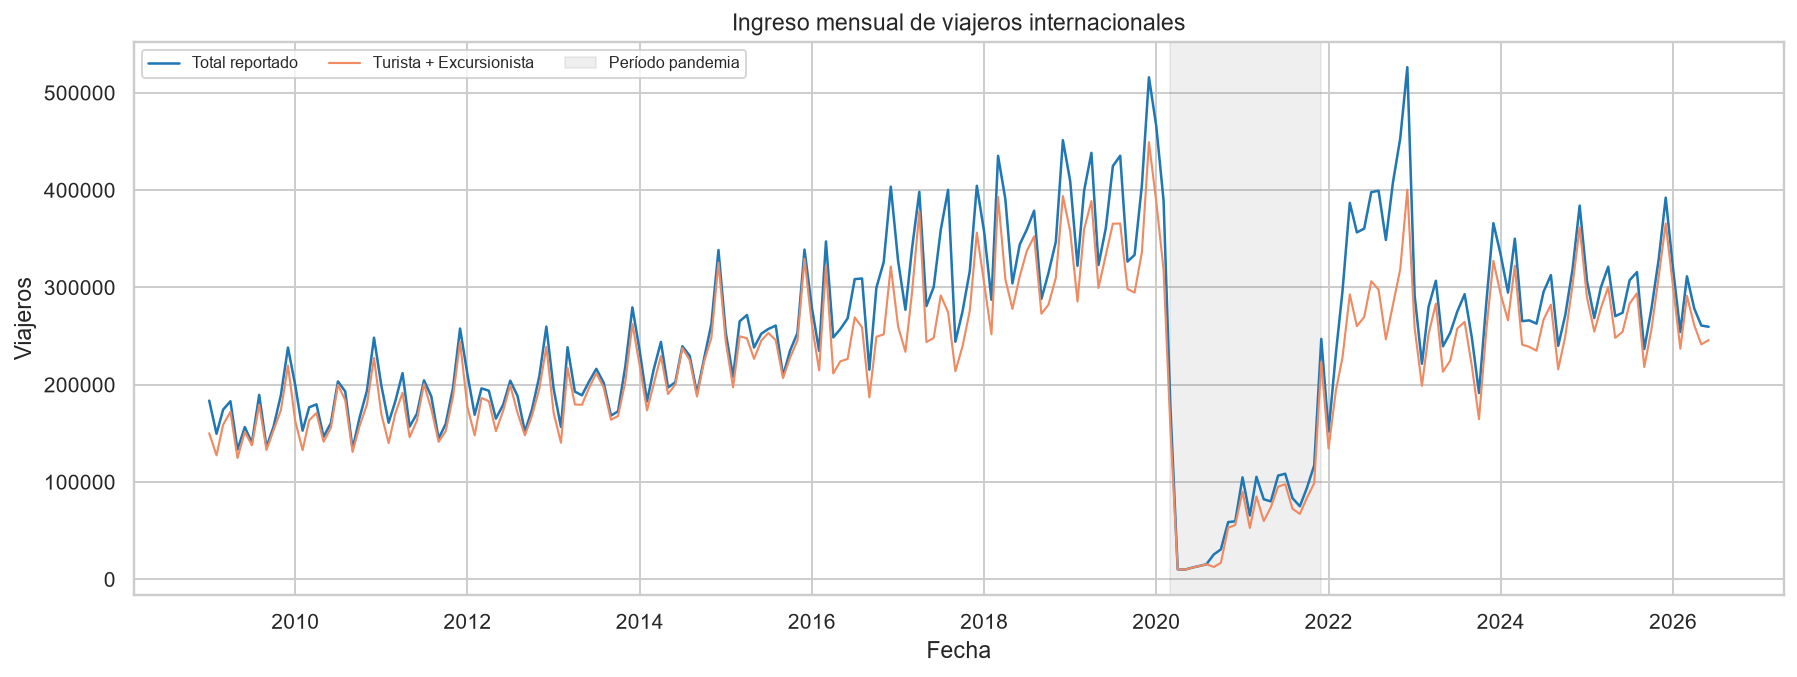

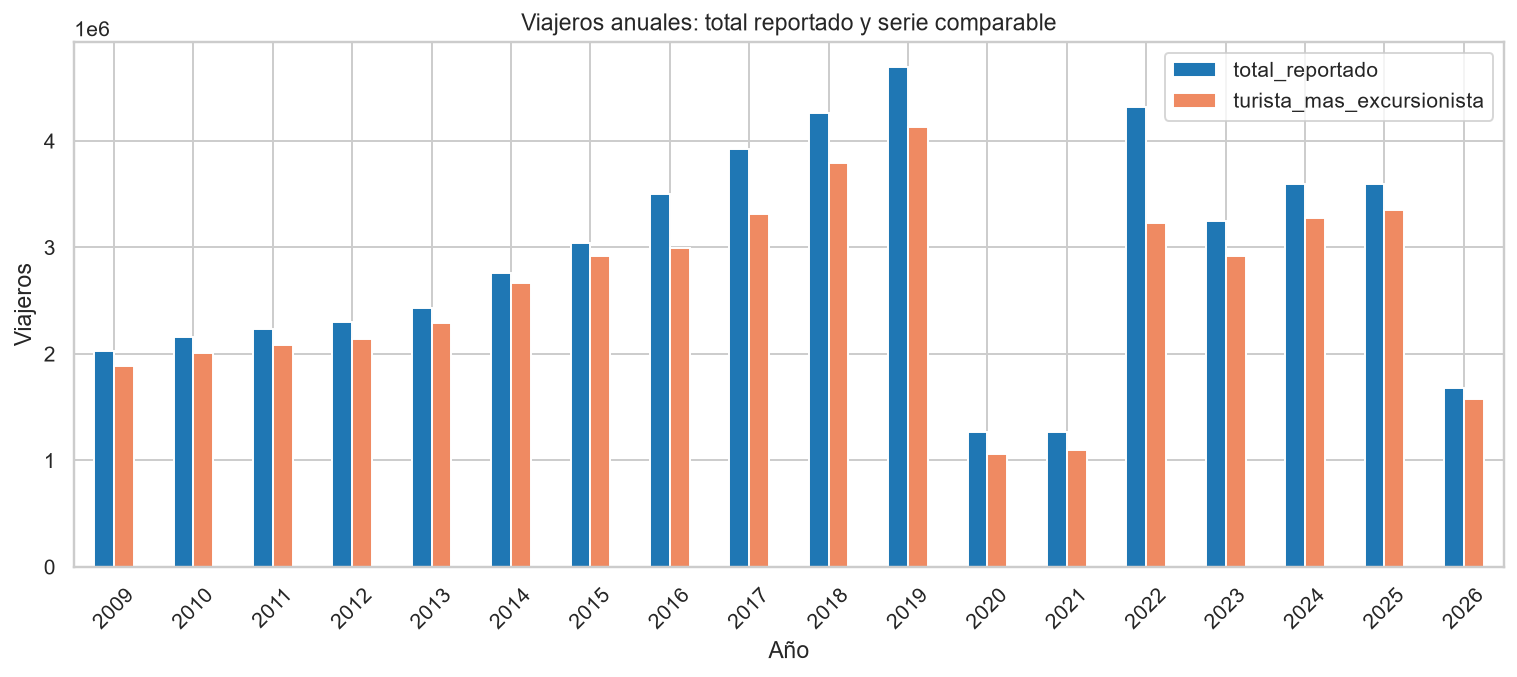

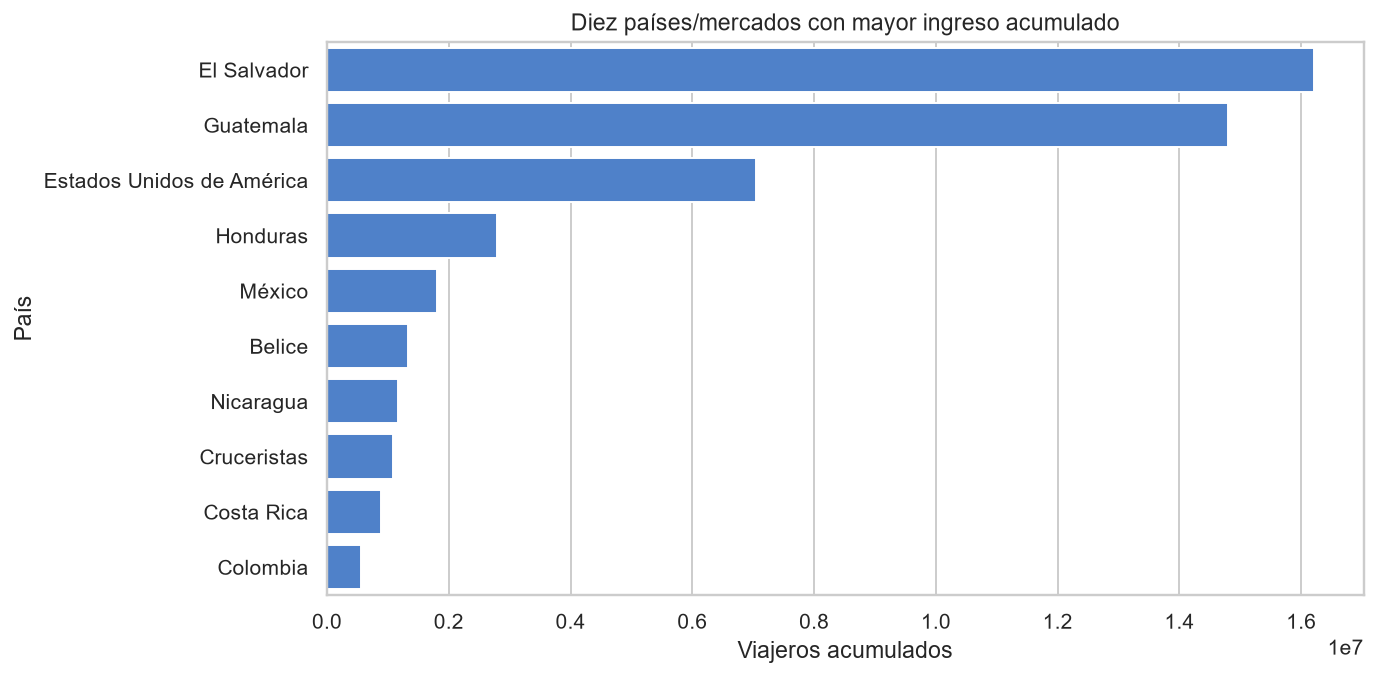

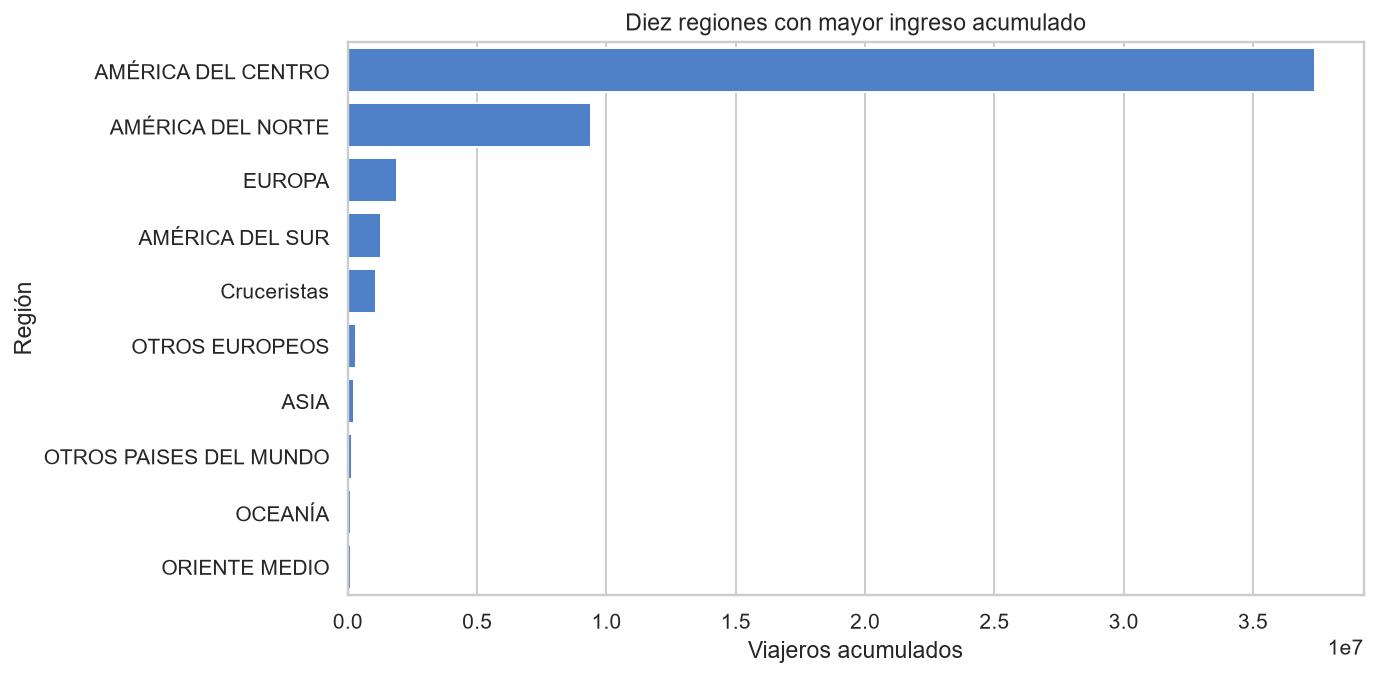

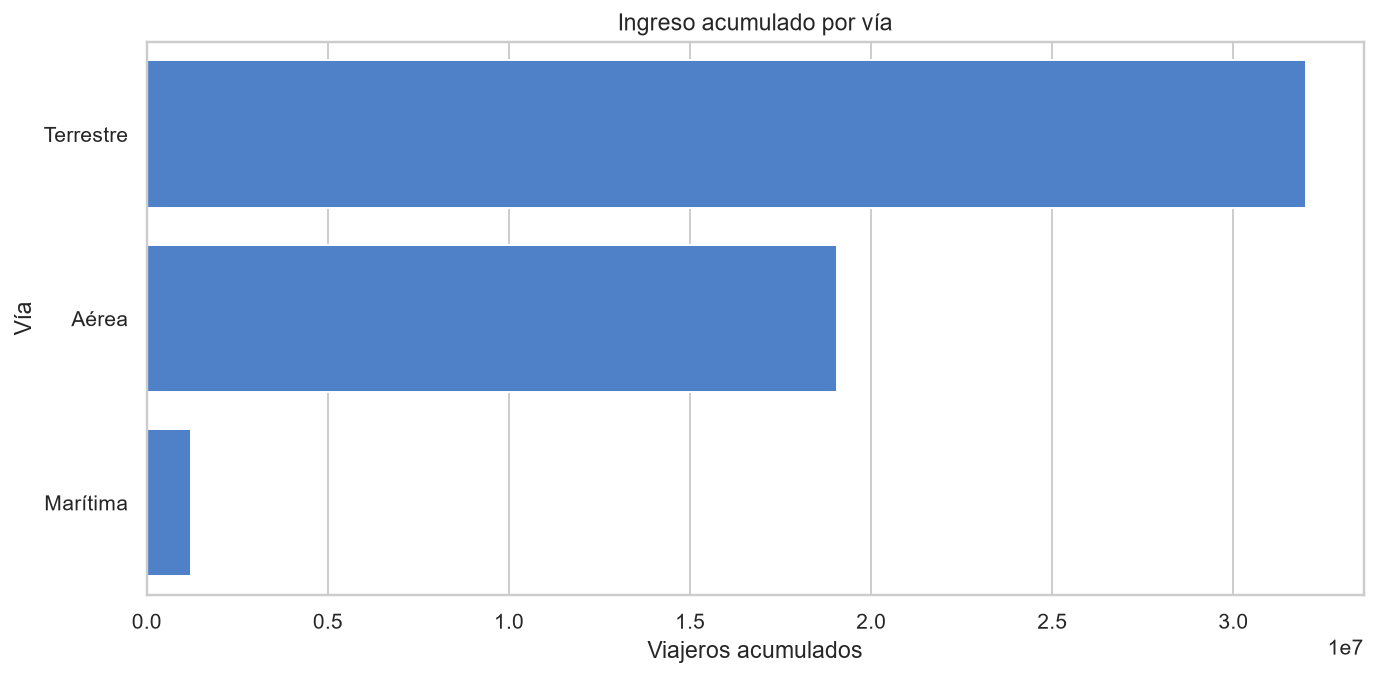

In [8]:
total = datos.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS', fill_value=0)
comparable = (datos.loc[datos['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].groupby('fecha')['Viajero'].sum().sort_index().reindex(total.index, fill_value=0))
series = pd.DataFrame({'total_reportado': total, 'turista_mas_excursionista': comparable})
anual = series.resample('YS').sum()
anual.index = anual.index.year
anual.index.name = 'año'
series.to_csv(OUT / 'series_totales_mensuales.csv', encoding='utf-8-sig')
anual.to_csv(OUT / 'resumen_anual.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(total, label='Total reportado', color='#1f77b4', linewidth=1.3)
ax.plot(comparable, label='Turista + Excursionista', color='#ef8a62', linewidth=1.1)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='grey', alpha=.12, label='Período pandemia')
ax.set(title='Ingreso mensual de viajeros internacionales', xlabel='Fecha', ylabel='Viajeros')
ax.legend(ncol=3, fontsize=8)
guardar(fig, '01_serie_total_mensual.png')
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
anual.plot(kind='bar', ax=ax, color=['#1f77b4', '#ef8a62'])
ax.set(title='Viajeros anuales: total reportado y serie comparable', xlabel='Año', ylabel='Viajeros')
ax.tick_params(axis='x', rotation=45)
guardar(fig, '02_resumen_anual.png')
plt.show()

for columna, archivo, titulo in [('País', '03_top_paises.png', 'Diez países/mercados con mayor ingreso acumulado'), ('Región', '04_top_regiones.png', 'Diez regiones con mayor ingreso acumulado'), ('Vía', '05_vias_ingreso.png', 'Ingreso acumulado por vía')]:
    top = datos.groupby(columna)['Viajero'].sum().sort_values(ascending=False).head(10)
    top.to_frame('viajeros').to_csv(OUT / f"top_{columna.lower().replace(' ', '_')}.csv", encoding='utf-8-sig')
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color='#3b7ddd')
    ax.set(title=titulo, xlabel='Viajeros acumulados', ylabel=columna)
    guardar(fig, archivo)
    plt.show()


### 1.3 Vías de ingreso y fronteras

Las tres vías se agregan por mes. La participación se calcula sobre todo el
período y las fronteras se examinan dentro de cada vía.


,viajeros_acumulados,participacion
Terrestre,3.199530e+07,61.19%
Aérea,1.906385e+07,36.46%
Marítima,1.228782e+06,2.35%


,Vía,Frontera,viajeros_acumulados,participacion_en_via
0,Aérea,01 La Aurora,1.902957e+07,99.82%
1,Aérea,02 Mundo Maya,3.426794e+04,0.18%
2,Aérea,20 Melchor de Mencos,1.500000e+01,0.00%
3,Marítima,03 Puerto Quetzal,7.415156e+05,60.35%
4,Marítima,04 Santo Tomás de Castilla,3.473774e+05,28.27%
5,Marítima,05 Puerto Barrios,6.224200e+04,5.07%
6,Marítima,06 Livingston,5.161700e+04,4.20%
7,Marítima,Cruceros,2.603000e+04,2.12%
10,Terrestre,07 Valle Nuevo,1.073234e+07,33.54%
12,Terrestre,09 San Cristóbal,5.363009e+06,16.76%


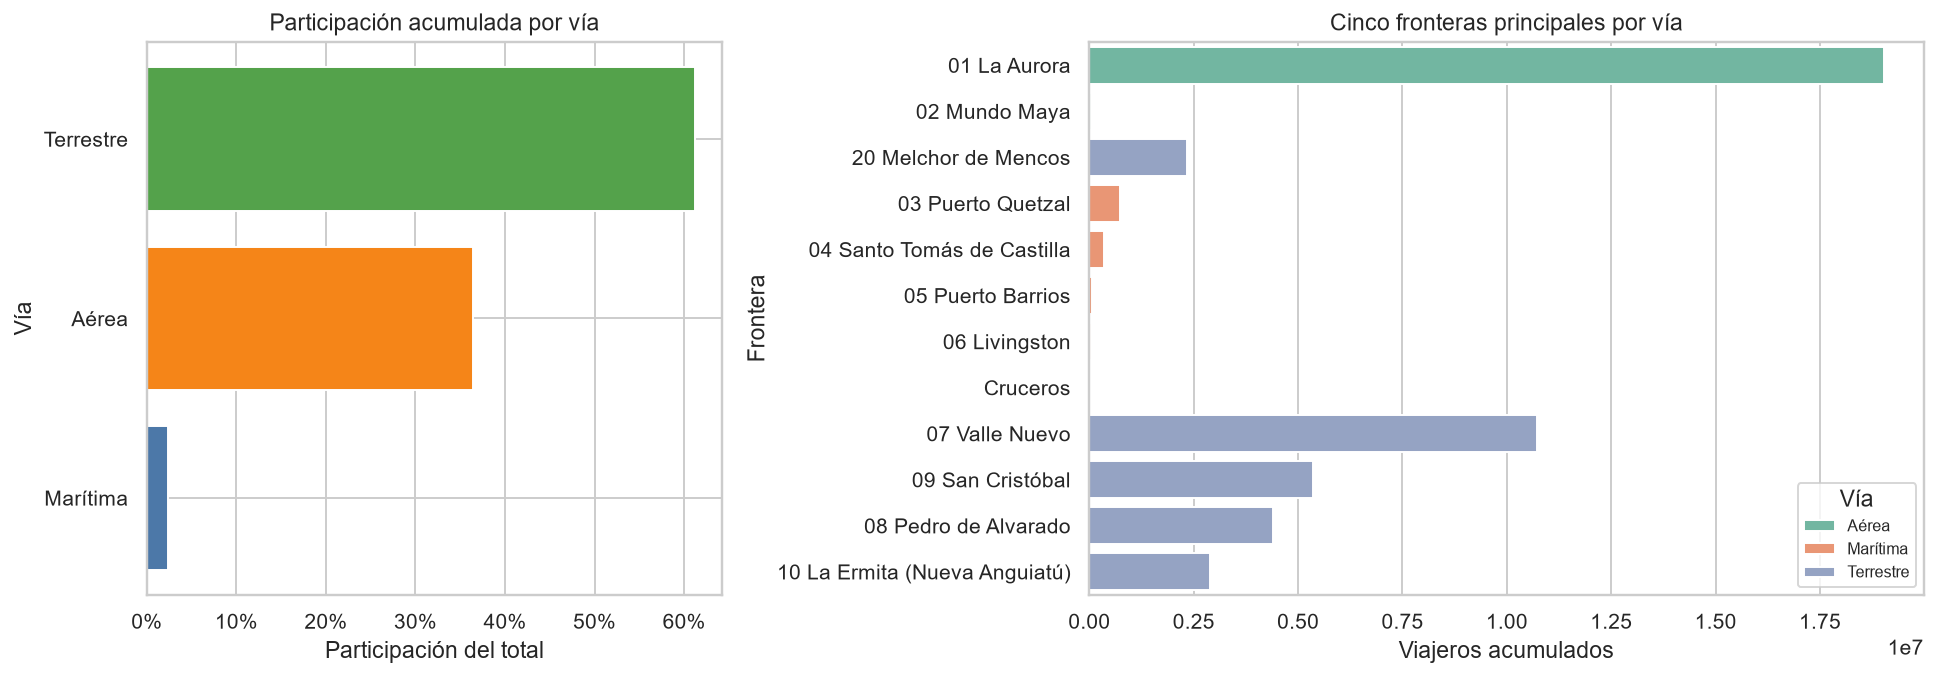

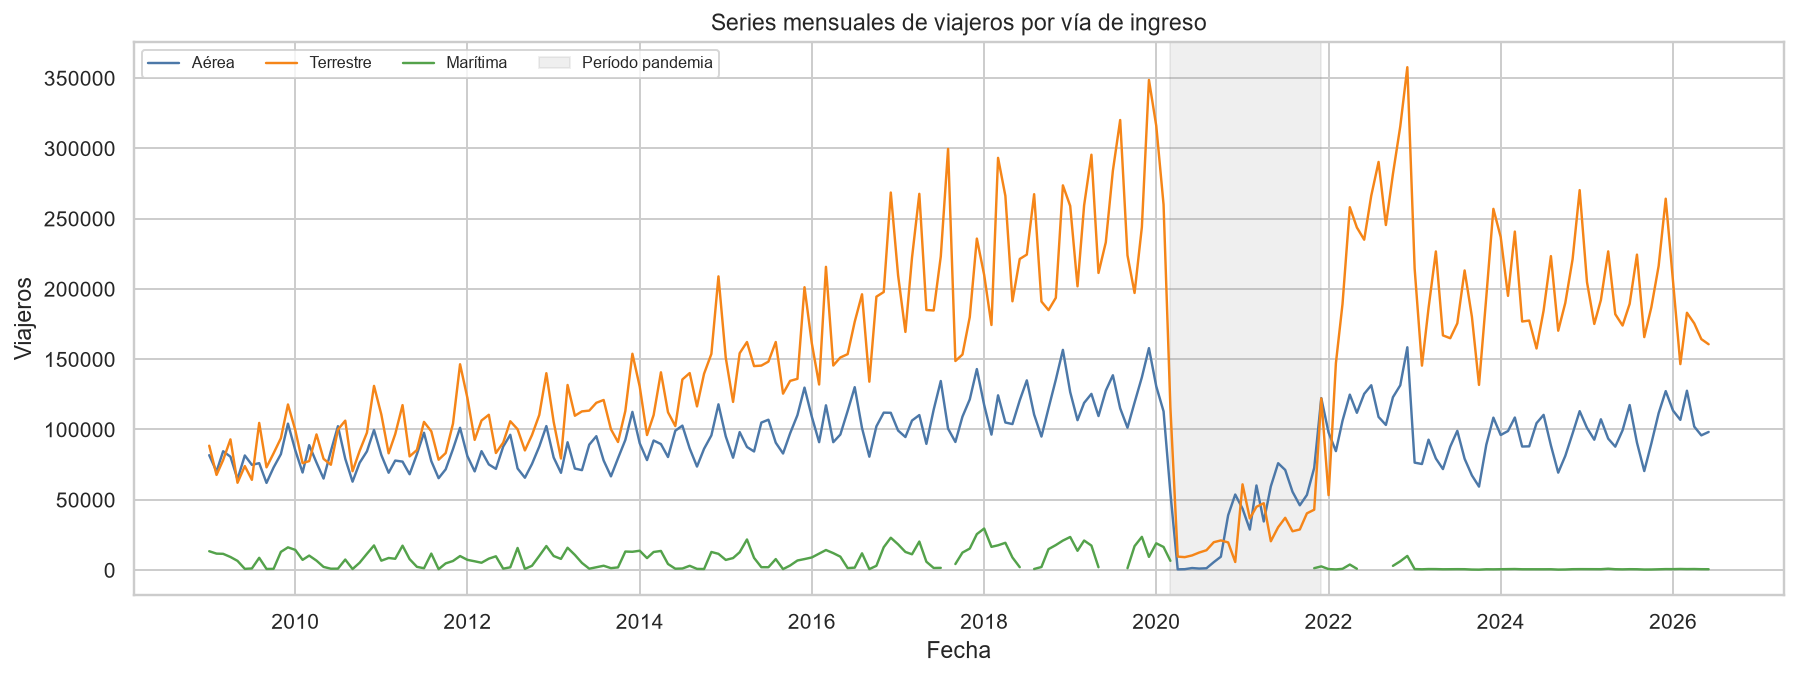

In [9]:
vias_orden = ['Aérea', 'Terrestre', 'Marítima']
series_vias = (datos.groupby(['fecha', 'Vía'])['Viajero'].sum()
                 .unstack('Vía')
                 .reindex(total.index, fill_value=0)
                 .reindex(columns=vias_orden, fill_value=0))
series_vias.index.name = 'fecha'
series_vias.columns.name = None
series_vias.to_csv(OUT / 'series_mensuales_por_via.csv', encoding='utf-8-sig')

participacion_vias = series_vias.sum().sort_values(ascending=False).to_frame('viajeros_acumulados')
participacion_vias['participacion'] = participacion_vias['viajeros_acumulados'] / participacion_vias['viajeros_acumulados'].sum()
participacion_vias.to_csv(OUT / 'participacion_por_via.csv', encoding='utf-8-sig')
display(participacion_vias.assign(participacion=lambda x: x['participacion'].map('{:.2%}'.format)))

fronteras = (datos.groupby(['Vía', 'Frontera'])['Viajero'].sum()
             .rename('viajeros_acumulados').reset_index())
fronteras['participacion_en_via'] = fronteras['viajeros_acumulados'] / fronteras.groupby('Vía')['viajeros_acumulados'].transform('sum')
fronteras = fronteras.sort_values(['Vía', 'viajeros_acumulados'], ascending=[True, False])
fronteras.to_csv(OUT / 'fronteras_por_via.csv', index=False, encoding='utf-8-sig')
top_fronteras = fronteras.groupby('Vía', group_keys=False).head(5).copy()
display(top_fronteras.assign(participacion_en_via=lambda x: x['participacion_en_via'].map('{:.2%}'.format)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.45]})
orden_participacion = participacion_vias.sort_values('viajeros_acumulados', ascending=True)
axes[0].barh(orden_participacion.index, orden_participacion['participacion'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set(title='Participación acumulada por vía', xlabel='Participación del total', ylabel='Vía')
sns.barplot(data=top_fronteras, x='viajeros_acumulados', y='Frontera', hue='Vía', dodge=False, ax=axes[1], palette='Set2')
axes[1].set(title='Cinco fronteras principales por vía', xlabel='Viajeros acumulados', ylabel='Frontera')
axes[1].legend(title='Vía', fontsize=8)
guardar(fig, '08_participacion_vias_y_fronteras.png')
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
for via, color in zip(vias_orden, ['#4c78a8', '#f58518', '#54a24b']):
    ax.plot(series_vias.index, series_vias[via], label=via, linewidth=1.25, color=color)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='grey', alpha=.12, label='Período pandemia')
ax.set(title='Series mensuales de viajeros por vía de ingreso', xlabel='Fecha', ylabel='Viajeros')
ax.legend(ncol=4, fontsize=8)
guardar(fig, '09_series_mensuales_por_via.png')
plt.show()


### 1.4 Países, `Región dos` y tipo de viajero

El Top 3 de `Región dos` se calcula con el acumulado de todo el período. Las
series regionales comparables utilizan `Turista + Excursionista`.


In [10]:
# Salidas específicas del análisis regional.
OUT = OUT_BASE / "regiones"
FIG = OUT / "figuras"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

datos_regiones = _cargar_datos()
(
    top3_regiones,
    series_regiones_todas,
    series_regiones_comparables,
) = _crear_series(datos_regiones)
ranking_paises_regiones, composicion_tipo_viajero = _eda(
    datos_regiones,
    top3_regiones,
    series_regiones_todas,
    series_regiones_comparables,
)

display(Markdown("#### Top 3 reproducible de `Región dos`"))
display(top3_regiones)
display(Markdown("#### Diez países o mercados con mayor acumulado"))
display(ranking_paises_regiones.head(10))
display(Markdown("#### Composición anual por tipo de viajero"))
display(composicion_tipo_viajero.tail())


#### Top 3 reproducible de `Región dos`

,viajeros_acumulados,participacion,posicion
region_dos,,,
América Del Centro,3.740653e+07,0.715406,1
América Del Norte,9.383035e+06,0.179452,2
Europa,2.222621e+06,0.042508,3


#### Diez países o mercados con mayor acumulado

,viajeros_acumulados,participacion
País,,
El Salvador,1.621398e+07,0.310090
Guatemala,1.479233e+07,0.282901
Estados Unidos de América,7.047843e+06,0.134789
Honduras,2.788233e+06,0.053325
México,1.808946e+06,0.034596
Belice,1.328256e+06,0.025403
Nicaragua,1.164343e+06,0.022268
Cruceristas,1.078372e+06,0.020624
Costa Rica,8.821797e+05,0.016872


#### Composición anual por tipo de viajero

Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Año,,,,
2022,26030.0,550371.000000,2.678958e+06,1.060806e+06
2023,0.0,793847.058304,2.123980e+06,3.308822e+05
2024,0.0,833527.486854,2.440909e+06,3.194400e+05
2025,0.0,811391.515466,2.540897e+06,2.449493e+05
2026,0.0,345939.379538,1.230680e+06,1.060165e+05


Las líneas rojas señalan el cambio de fuente de 2023 y el sombreado gris el
período de mayor afectación pandémica.

![Series mensuales del Top 3](resultados_laboratorio_1/regiones/figuras/10_series_top3_region_dos.png)

La composición por tipo evidencia por qué `Viajero` y cruceristas deben
mantenerse separados del indicador comparable de visitas.

![Composición por tipo de viajero](resultados_laboratorio_1/regiones/figuras/11_tipo_viajero_anual.png)


## 2. División en entrenamiento y prueba

La partición conserva el orden temporal: aproximadamente 70% de las
observaciones se usan para entrenamiento y el 30% final para prueba. El mismo
corte se utiliza en todas las series.


In [11]:
n_observaciones = len(total)
n_entrenamiento = math.floor(0.70 * n_observaciones)
n_prueba = n_observaciones - n_entrenamiento

particion_temporal = pd.DataFrame(
    {
        "Conjunto": ["Entrenamiento", "Prueba"],
        "Observaciones": [n_entrenamiento, n_prueba],
        "Porcentaje": [
            n_entrenamiento / n_observaciones,
            n_prueba / n_observaciones,
        ],
        "Inicio": [
            total.index[0].strftime("%Y-%m"),
            total.index[n_entrenamiento].strftime("%Y-%m"),
        ],
        "Fin": [
            total.index[n_entrenamiento - 1].strftime("%Y-%m"),
            total.index[-1].strftime("%Y-%m"),
        ],
    }
)
display(
    particion_temporal.style.format(
        {"Porcentaje": "{:.1%}"}
    )
)


,Conjunto,Observaciones,Porcentaje,Inicio,Fin
0,Entrenamiento,147,70.0%,2009-01,2021-03
1,Prueba,63,30.0%,2021-04,2026-06


## 3. Construcción de las series mensuales

Se construye la serie total obligatoria, una serie para cada vía de ingreso y
una serie para cada una de las tres regiones principales. Todas mantienen
frecuencia mensual continua.


In [12]:
series_laboratorio = pd.concat(
    [
        total.rename("Total mensual"),
        series_vias.fillna(0).rename(
            columns={
                "Aérea": "Vía aérea",
                "Terrestre": "Vía terrestre",
                "Marítima": "Vía marítima",
            }
        ),
        series_regiones_comparables.add_prefix("Región: "),
    ],
    axis=1,
)
series_laboratorio.index.name = "fecha"

indice_mensual = pd.date_range(
    series_laboratorio.index.min(),
    series_laboratorio.index.max(),
    freq="MS",
)
assert series_laboratorio.index.equals(indice_mensual)
assert series_laboratorio.shape[1] == 7
assert not series_laboratorio.isna().any().any()

resumen_series_laboratorio = pd.DataFrame(
    {
        "Serie": series_laboratorio.columns,
        "Inicio": series_laboratorio.index.min().strftime("%Y-%m"),
        "Fin": series_laboratorio.index.max().strftime("%Y-%m"),
        "Frecuencia": "Mensual",
        "Observaciones": len(series_laboratorio),
        "Entrenamiento": n_entrenamiento,
        "Prueba": n_prueba,
    }
)
display(resumen_series_laboratorio)


,Serie,Inicio,Fin,Frecuencia,Observaciones,Entrenamiento,Prueba
0,Total mensual,2009-01,2026-06,Mensual,210,147,63
1,Vía aérea,2009-01,2026-06,Mensual,210,147,63
2,Vía terrestre,2009-01,2026-06,Mensual,210,147,63
3,Vía marítima,2009-01,2026-06,Mensual,210,147,63
4,Región: América Del Centro,2009-01,2026-06,Mensual,210,147,63
5,Región: América Del Norte,2009-01,2026-06,Mensual,210,147,63
6,Región: Europa,2009-01,2026-06,Mensual,210,147,63


## 4. Análisis y modelado de cada serie

Para cada serie se documentan cobertura, descomposición, estacionariedad,
transformación, ACF/PACF, parámetros ARIMA/SARIMA, modelos alternativos,
predicción, métricas y residuos.


### 4.1 Serie total mensual y vía aérea

Primero se presentan los diagnósticos individuales y luego la comparación
completa de modelos para ambas series.


#### 4.1.1 Diagnóstico de la serie total mensual


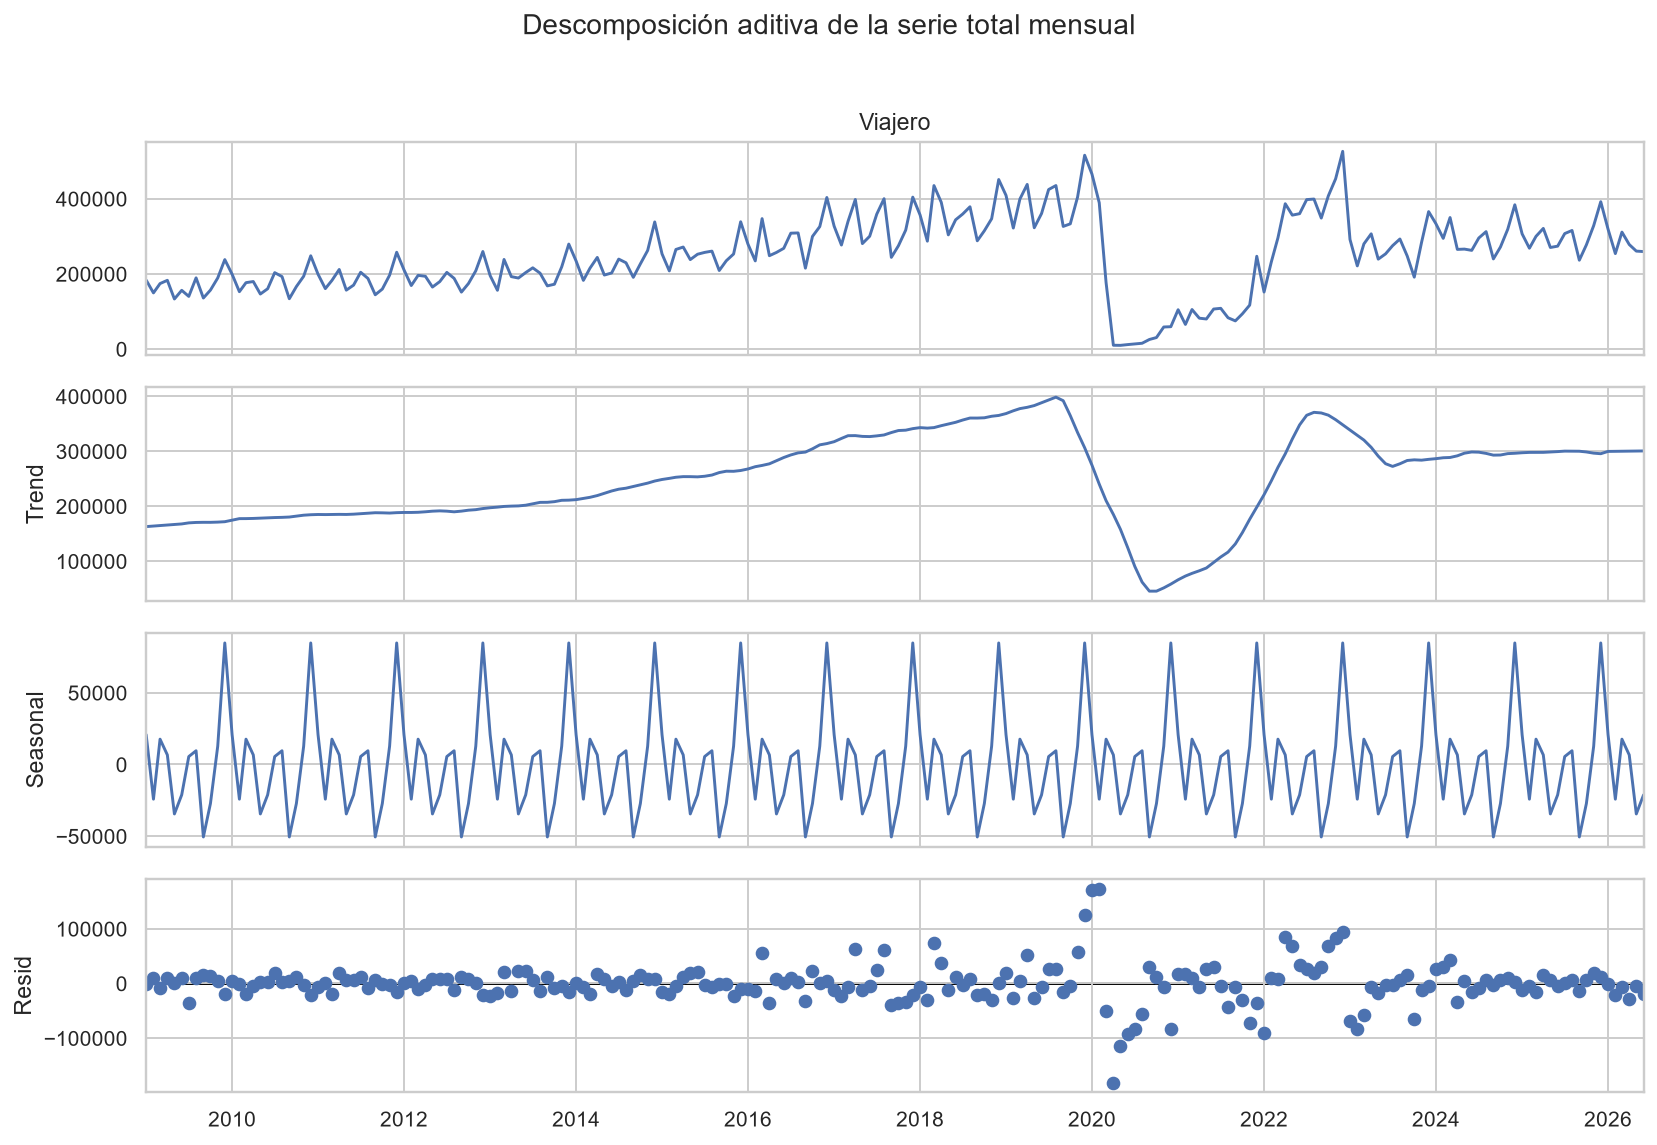

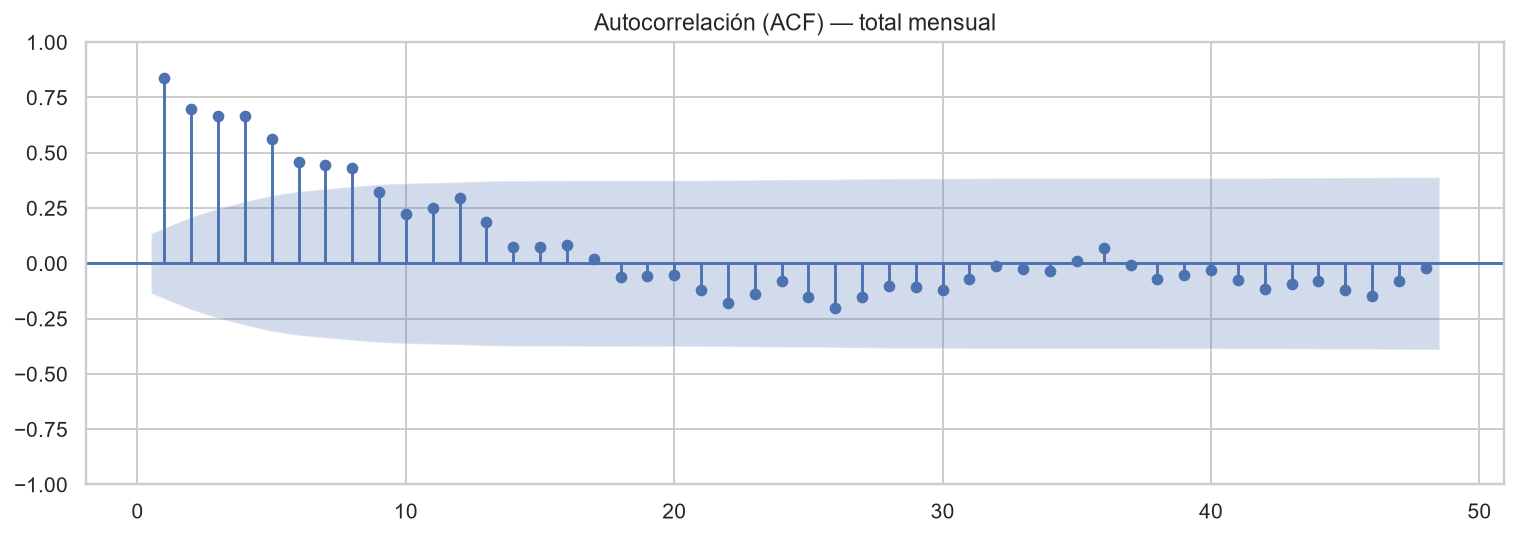

,Métrica,Valor
0,Inicio,2009-01
1,Fin,2026-06
2,Frecuencia,Mensual
3,Observaciones,210
4,Media mensual,248990.176637
5,Desviación estándar,100744.492958
6,Coeficiente de variación,0.404612
7,ACF rezago 1,0.838517
8,ACF rezago 12,0.307044
9,ADF nivel: estadístico,-3.070206


In [13]:
OUT = OUT_BASE
FIG = OUT / 'figuras'
FIG.mkdir(parents=True, exist_ok=True)

descomp = seasonal_decompose(total, model='additive', period=12, extrapolate_trend='freq')
fig = descomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Descomposición aditiva de la serie total mensual', y=1.02)
guardar(fig, '06_descomposicion_total.png')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(total, lags=min(48, len(total)//2 - 1), ax=ax, zero=False)
ax.set_title('Autocorrelación (ACF) — total mensual')
guardar(fig, '07_acf_total.png')
plt.show()

adf_nivel = adfuller(total, autolag='AIC')
adf_diff = adfuller(total.diff().dropna(), autolag='AIC')
diagnostico = pd.DataFrame({'Métrica': ['Inicio', 'Fin', 'Frecuencia', 'Observaciones', 'Media mensual', 'Desviación estándar', 'Coeficiente de variación', 'ACF rezago 1', 'ACF rezago 12', 'ADF nivel: estadístico', 'ADF nivel: p-valor', 'ADF primera diferencia: estadístico', 'ADF primera diferencia: p-valor'],
                           'Valor': [total.index.min().strftime('%Y-%m'), total.index.max().strftime('%Y-%m'), 'Mensual', len(total), total.mean(), total.std(), total.std()/total.mean(), total.autocorr(1), total.autocorr(12), adf_nivel[0], adf_nivel[1], adf_diff[0], adf_diff[1]]})
display(diagnostico)
diagnostico.to_csv(OUT / 'diagnostico_serie_total.csv', index=False, encoding='utf-8-sig')


In [14]:
top_pais = datos.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top_region = datos.groupby('Región')['Viajero'].sum().sort_values(ascending=False)
top_via = datos.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
cambio_2023 = anual.loc[2023, 'total_reportado'] / anual.loc[2022, 'total_reportado'] - 1
caida_2020 = anual.loc[2020, 'total_reportado'] / anual.loc[2019, 'total_reportado'] - 1
conclusion_adf = 'se rechaza' if adf_nivel[1] < .05 else 'no se rechaza'

display(Markdown(f'''
### Hallazgos principales

- La serie total tiene **{len(total)} observaciones mensuales**, desde **{total.index.min():%Y-%m}** hasta **{total.index.max():%Y-%m}**.
- La caída anual entre 2019 y 2020 fue de **{caida_2020:.1%}**, lo que evidencia el impacto de la pandemia.
- Entre 2022 y 2023 el total reportado cambió **{cambio_2023:.1%}**. Este resultado debe interpretarse junto con el cambio de definición de `Viajero` indicado en el enunciado.
- El principal país/mercado es **{top_pais.index[0]}** ({top_pais.iloc[0] / top_pais.sum():.1%} del acumulado), la región líder es **{top_region.index[0]}** ({top_region.iloc[0] / top_region.sum():.1%}) y la vía dominante es **{top_via.index[0]}** ({top_via.iloc[0] / top_via.sum():.1%}).
- La ACF es alta en el rezago 1 ({total.autocorr(1):.3f}) y conserva asociación en el rezago 12 ({total.autocorr(12):.3f}), por lo que se evaluarán modelos estacionales.
- La ADF en nivel tiene p-valor **{adf_nivel[1]:.4f}**: al 5%, **{conclusion_adf}** la hipótesis nula de raíz unitaria. Como hay quiebres estructurales, se compararán modelos con `d=0` y, si los diagnósticos lo requieren, `d=1`; la diferenciación estacional de período 12 se probará solo si se justifica.
- Los registros atípicos no se eliminaron automáticamente, pues pueden corresponder a flujos reales agregados.
'''))



### Hallazgos principales

- La serie total tiene **210 observaciones mensuales**, desde **2009-01** hasta **2026-06**.
- La caída anual entre 2019 y 2020 fue de **-73.0%**, lo que evidencia el impacto de la pandemia.
- Entre 2022 y 2023 el total reportado cambió **-24.7%**. Este resultado debe interpretarse junto con el cambio de definición de `Viajero` indicado en el enunciado.
- El principal país/mercado es **El Salvador** (31.0% del acumulado), la región líder es **AMÉRICA DEL CENTRO** (71.5%) y la vía dominante es **Terrestre** (61.2%).
- La ACF es alta en el rezago 1 (0.839) y conserva asociación en el rezago 12 (0.307), por lo que se evaluarán modelos estacionales.
- La ADF en nivel tiene p-valor **0.0288**: al 5%, **se rechaza** la hipótesis nula de raíz unitaria. Como hay quiebres estructurales, se compararán modelos con `d=0` y, si los diagnósticos lo requieren, `d=1`; la diferenciación estacional de período 12 se probará solo si se justifica.
- Los registros atípicos no se eliminaron automáticamente, pues pueden corresponder a flujos reales agregados.


#### 4.1.2 Diagnóstico de la vía aérea


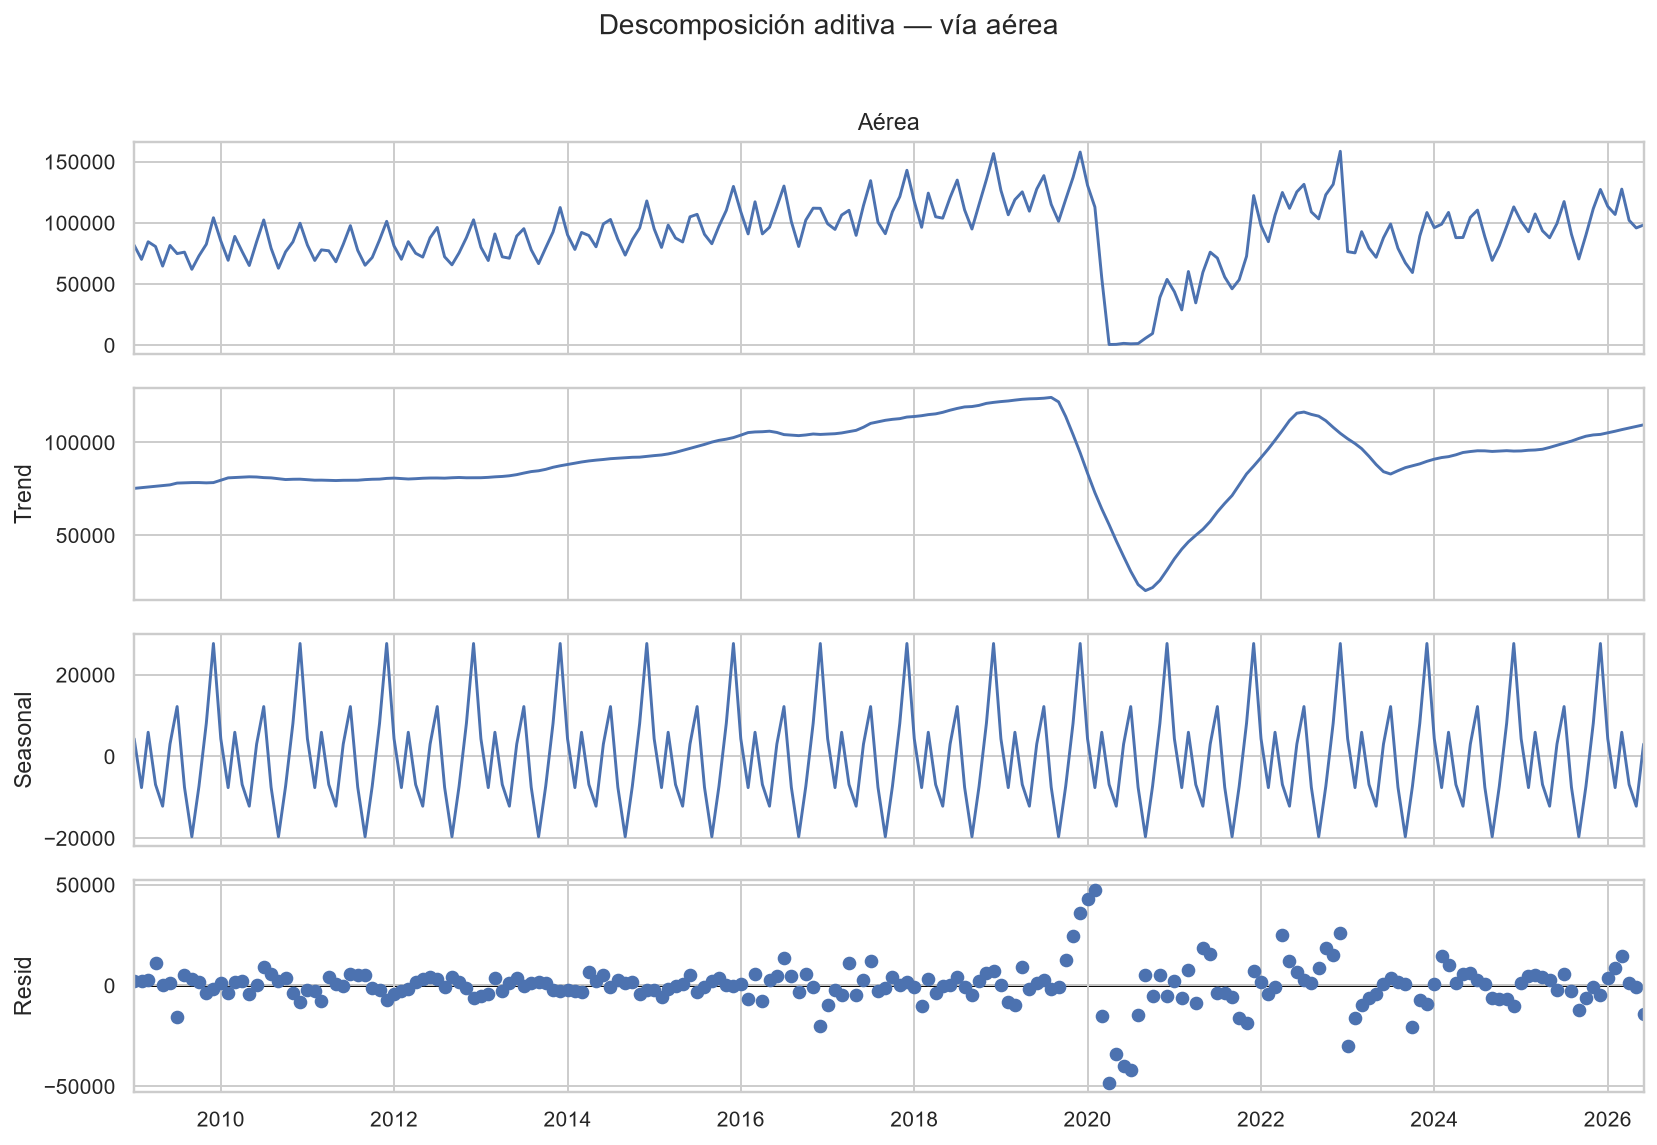

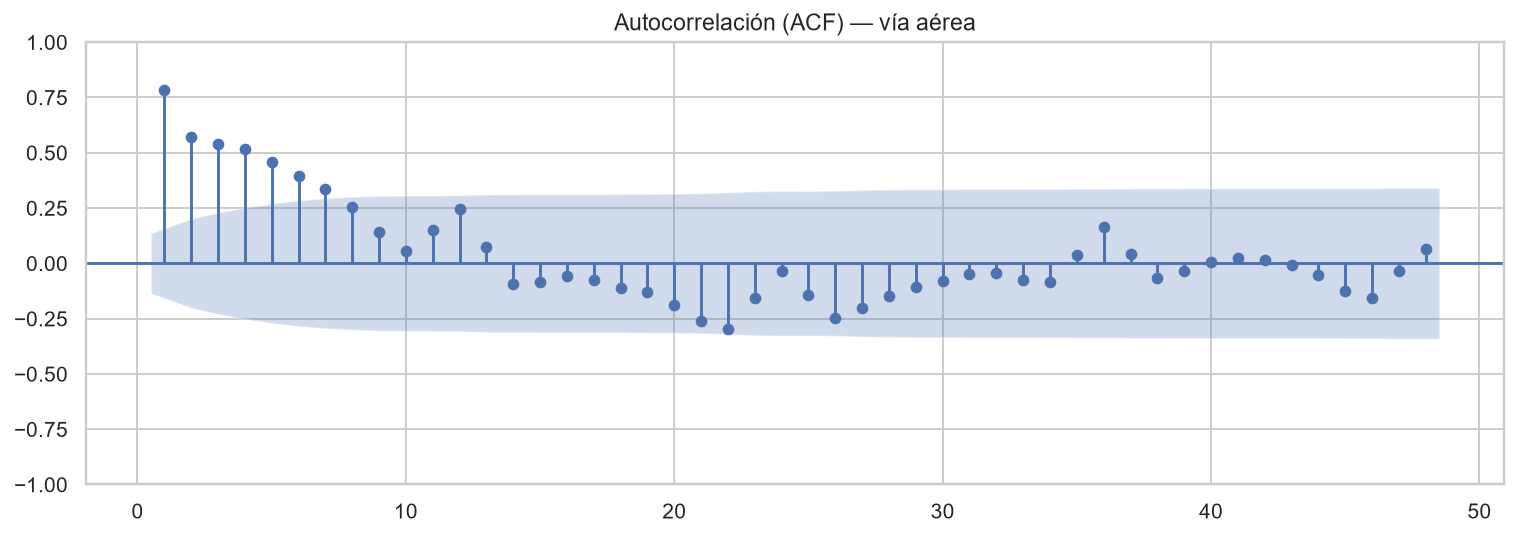

,Métrica,Valor
0,Inicio,2009-01
1,Fin,2026-06
2,Frecuencia,Mensual
3,Observaciones,210
4,Media mensual,90780.238988
5,Desviación estándar,27728.032327
6,Coeficiente de variación,0.305441
7,Mínimo mensual,489.0
8,Máximo mensual,158463.0
9,ACF rezago 1,0.782487



### Interpretación de la vía aérea

- La serie aérea contiene **210 observaciones mensuales**, de **2009-01** a **2026-06**, sin huecos tras la agregación mensual.
- La frontera aérea con mayor flujo acumulado es **01 La Aurora**, con **99.8%** de los viajeros que ingresan por esta vía.
- La descomposición permite separar una tendencia afectada por la pandemia y el cambio de definición posterior a 2022, de un patrón estacional mensual que se evaluará formalmente en el modelado.
- La ACF es 0.782 en el rezago 1 y 0.251 en el rezago 12; por ello se compararán especificaciones con componente estacional de período 12.
- ADF en nivel: p-valor **0.0203**; al 5%, se rechaza la hipótesis nula de raíz unitaria. La decisión es probar **d=0 como primer candidato**, sin omitir alternativas por los quiebres estructurales.
- La escala original puede conservarse como referencia; se comparará log1p en los modelos para estabilizar la amplitud.


In [15]:
aerea = series_vias['Aérea'].asfreq('MS', fill_value=0)
descomp_aerea = seasonal_decompose(aerea, model='additive', period=12, extrapolate_trend='freq')
fig = descomp_aerea.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Descomposición aditiva — vía aérea', y=1.02)
guardar(fig, '10_descomposicion_aerea.png')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(aerea, lags=min(48, len(aerea)//2 - 1), ax=ax, zero=False)
ax.set_title('Autocorrelación (ACF) — vía aérea')
guardar(fig, '11_acf_aerea.png')
plt.show()

adf_aerea_nivel = adfuller(aerea, autolag='AIC')
adf_aerea_log = adfuller(np.log1p(aerea), autolag='AIC')
adf_aerea_diff = adfuller(aerea.diff().dropna(), autolag='AIC')
diagnostico_aerea = pd.DataFrame({
    'Métrica': ['Inicio', 'Fin', 'Frecuencia', 'Observaciones', 'Media mensual', 'Desviación estándar',
                'Coeficiente de variación', 'Mínimo mensual', 'Máximo mensual', 'ACF rezago 1', 'ACF rezago 12',
                'ADF nivel: estadístico', 'ADF nivel: p-valor', 'ADF log1p: p-valor',
                'ADF primera diferencia: estadístico', 'ADF primera diferencia: p-valor'],
    'Valor': [aerea.index.min().strftime('%Y-%m'), aerea.index.max().strftime('%Y-%m'), 'Mensual', len(aerea),
              aerea.mean(), aerea.std(), aerea.std()/aerea.mean(), aerea.min(), aerea.max(),
              aerea.autocorr(1), aerea.autocorr(12), adf_aerea_nivel[0], adf_aerea_nivel[1],
              adf_aerea_log[1], adf_aerea_diff[0], adf_aerea_diff[1]]
})
display(diagnostico_aerea)
diagnostico_aerea.to_csv(OUT / 'diagnostico_serie_aerea.csv', index=False, encoding='utf-8-sig')

p_adf_aerea = adf_aerea_nivel[1]
decision_d = 'd=0 como primer candidato' if p_adf_aerea < .05 else 'd=1 como primer candidato'
decision_transformacion = ('La escala original puede conservarse como referencia; se comparará log1p en los modelos para estabilizar la amplitud.'
                            if aerea.std()/aerea.mean() >= .30 else
                            'No hay evidencia descriptiva suficiente para exigir transformación; se conservará la escala original como referencia.')
top_aerea = fronteras.loc[fronteras['Vía'].eq('Aérea')].iloc[0]
display(Markdown(f'''
### Interpretación de la vía aérea

- La serie aérea contiene **{len(aerea)} observaciones mensuales**, de **{aerea.index.min():%Y-%m}** a **{aerea.index.max():%Y-%m}**, sin huecos tras la agregación mensual.
- La frontera aérea con mayor flujo acumulado es **{top_aerea['Frontera']}**, con **{top_aerea['participacion_en_via']:.1%}** de los viajeros que ingresan por esta vía.
- La descomposición permite separar una tendencia afectada por la pandemia y el cambio de definición posterior a 2022, de un patrón estacional mensual que se evaluará formalmente en el modelado.
- La ACF es {aerea.autocorr(1):.3f} en el rezago 1 y {aerea.autocorr(12):.3f} en el rezago 12; por ello se compararán especificaciones con componente estacional de período 12.
- ADF en nivel: p-valor **{p_adf_aerea:.4f}**; al 5%, {'se rechaza' if p_adf_aerea < .05 else 'no se rechaza'} la hipótesis nula de raíz unitaria. La decisión es probar **{decision_d}**, sin omitir alternativas por los quiebres estructurales.
- {decision_transformacion}
'''))


#### 4.1.3 Modelos, predicciones y selección

Se comparan ARIMA/SARIMA, Prophet, Holt-Winters, suavizamiento exponencial
simple y seasonal naïve con la partición temporal definida.


In [16]:
# Las funciones de modelado se definieron en la sección de Región dos.
# Aquí se reutilizan sin modificar los análisis de las otras series.
OUT = ROOT / 'resultados_laboratorio_1' / 'series_total_y_aerea'
FIG = OUT / 'figuras'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

aerea_final = (datos.loc[datos['Vía'].eq('Aérea')]
               .groupby('fecha')['Viajero'].sum()
               .sort_index().reindex(total.index, fill_value=0).astype(float))
series_finales_p1 = pd.DataFrame({
    'Total mensual': total.astype(float),
    'Vía aérea': aerea_final,
})
series_finales_p1.index.name = 'fecha'

indice_esperado = pd.date_range(series_finales_p1.index.min(), series_finales_p1.index.max(), freq='MS')
assert series_finales_p1.index.equals(indice_esperado), 'Las series deben tener frecuencia mensual continua.'
assert not series_finales_p1.isna().any().any(), 'No deben existir faltantes en las series agregadas.'
assert (series_finales_p1 >= 0).all().all(), 'Las series no pueden contener cantidades negativas.'

resumen_p1, adf_p1, d_p1 = _diagnostico_series(series_finales_p1)
impacto_p1 = _impacto_pandemia(series_finales_p1)
modelos_p1, arimas_p1, predicciones_p1, residuos_p1 = _evaluar_modelos(series_finales_p1, d_p1)
componentes_p1 = _fuerza_componentes(series_finales_p1)

selecciones_p1 = (modelos_p1.loc[modelos_p1['seleccion_final']]
                  .sort_values('region')
                  .reset_index(drop=True))
series_finales_p1.to_csv(OUT / 'series_total_y_aerea.csv', encoding='utf-8-sig')
resumen_p1.to_csv(OUT / 'resumen_diagnostico.csv', index=False, encoding='utf-8-sig')
componentes_p1.to_csv(OUT / 'componentes_tendencia_estacionalidad.csv', index=False, encoding='utf-8-sig')
impacto_p1.to_csv(OUT / 'impacto_pandemia.csv', index=False, encoding='utf-8-sig')
modelos_p1.to_csv(OUT / 'comparacion_modelos.csv', index=False, encoding='utf-8-sig')
arimas_p1.to_csv(OUT / 'candidatos_arima_sarima.csv', index=False, encoding='utf-8-sig')
predicciones_p1.to_csv(OUT / 'predicciones_prueba.csv', index=False, encoding='utf-8-sig')
residuos_p1.to_csv(OUT / 'residuos_modelos_seleccionados.csv', index=False, encoding='utf-8-sig')

display(Markdown('### Diagnóstico de estacionariedad y componentes'))
display(resumen_p1)
display(Markdown('### Comparación de modelos (menor RMSE es mejor)'))
display(modelos_p1.sort_values(['region', 'RMSE']).reset_index(drop=True))
display(Markdown('### Modelo seleccionado por serie'))
display(selecciones_p1[['region', 'modelo', 'configuracion', 'MAE', 'RMSE', 'AIC', 'BIC', 'ljung_box_p_12']])


### Diagnóstico de estacionariedad y componentes

,region,inicio,fin,frecuencia,observaciones,media,desviacion_estandar,coeficiente_variacion,acf_rezago_1,acf_rezago_12,razon_varianza_segunda_primera_mitad,transformacion_propuesta,d_sugerido_adf_log1p,D_estacional_propuesto,p_q_a_comparar
0,Total mensual,2009-01,2026-06,Mensual,210,248990.176637,100744.492958,0.404612,0.838517,0.307044,4.065648,"log1p: estabiliza la varianza, admite ceros y ...",0,1,"p∈{0,1,2}; q∈{0,1}; selección por AIC y RMSE"
1,Vía aérea,2009-01,2026-06,Mensual,210,90780.238988,27728.032327,0.305441,0.782487,0.251189,5.267292,"log1p: estabiliza la varianza, admite ceros y ...",0,1,"p∈{0,1,2}; q∈{0,1}; selección por AIC y RMSE"


### Comparación de modelos (menor RMSE es mejor)

,region,modelo,inicio_train,fin_train,inicio_prueba,fin_prueba,n_train,n_prueba,MAE,RMSE,...,BIC,escala_AIC_BIC,configuracion,escala_residuos,media_residuos,desviacion_residuos,ljung_box_p_12,jarque_bera_p,mejor_por_rmse,seleccion_final
0,Total mensual,ARIMA/SARIMA seleccionado,2009-01,2021-03,2021-04,2026-06,147,63,100904.019566,112077.655931,...,202.677681,log1p,"SARIMA(0, 0, 1)x(0, 1, 1, 12)",log1p,0.031063,0.502176,1.682451e-38,1.144893e-215,True,False
1,Total mensual,Suavizamiento exponencial simple,2009-01,2021-03,2021-04,2026-06,147,63,180675.084649,200663.557361,...,3223.196708,original,,original,-665.974366,55974.265117,1.292629e-18,1.815757e-10,False,False
2,Total mensual,Holt-Winters,2009-01,2021-03,2021-04,2026-06,147,63,188111.777203,205437.845606,...,3189.392410,original,,original,-595.015820,38677.175488,7.520611e-01,0.000000e+00,False,True
3,Total mensual,Seasonal naïve,2009-01,2021-03,2021-04,2026-06,147,63,235730.913810,253203.387828,...,NaN,no aplica,,original,-11252.441602,112295.096082,2.412344e-80,1.138248e-86,False,False
4,Total mensual,Prophet,2009-01,2021-03,2021-04,2026-06,147,63,258367.271546,281496.095381,...,NaN,no disponible,,original,-172.656700,62950.824746,1.461314e-54,2.089401e-15,False,False
5,Vía aérea,ARIMA/SARIMA seleccionado,2009-01,2021-03,2021-04,2026-06,147,63,24962.468975,30140.197383,...,198.847574,log1p,"ARIMA(1, 0, 1)",log1p,-0.003825,0.482749,5.283097e-01,0.000000e+00,True,True
6,Vía aérea,Suavizamiento exponencial simple,2009-01,2021-03,2021-04,2026-06,147,63,36108.526737,41367.771433,...,2881.296630,original,,original,-144.028709,17496.550424,3.307982e-19,6.008080e-02,False,False
7,Vía aérea,Holt-Winters,2009-01,2021-03,2021-04,2026-06,147,63,37427.230376,41498.635374,...,2789.391619,original,,original,-113.443064,9922.015383,2.482588e-01,0.000000e+00,False,False
8,Vía aérea,Seasonal naïve,2009-01,2021-03,2021-04,2026-06,147,63,75103.700079,79077.334766,...,NaN,no aplica,,original,-5112.384316,32472.015339,8.698368e-87,6.919352e-95,False,False
9,Vía aérea,Prophet,2009-01,2021-03,2021-04,2026-06,147,63,86604.504648,91458.746091,...,NaN,no disponible,,original,-82.607845,18898.435875,3.231398e-56,4.007640e-23,False,False


### Modelo seleccionado por serie

,region,modelo,configuracion,MAE,RMSE,AIC,BIC,ljung_box_p_12
0,Total mensual,Holt-Winters,,188111.777203,205437.845606,3138.555056,3189.392410,0.752061
1,Vía aérea,ARIMA/SARIMA seleccionado,"ARIMA(1, 0, 1)",24962.468975,30140.197383,186.940639,198.847574,0.528310


#### Conclusiones de la serie total y la vía aérea

La selección final prioriza el **RMSE del conjunto de prueba**, siempre que los residuos no presenten autocorrelación significativa según Ljung-Box (p ≥ 0.05). AIC y BIC se usan únicamente para contrastar los candidatos ARIMA/SARIMA, pues los demás métodos se ajustan en escalas o formulaciones distintas.


In [17]:
resumen_i = resumen_p1.set_index('region')
adf_log = (adf_p1.loc[adf_p1['transformacion'].eq('log1p')]
           .set_index('region')['p_valor'])
impacto_i = impacto_p1.set_index('region')
componentes_i = componentes_p1.set_index('region')
seleccion_i = selecciones_p1.set_index('region')

lineas = ['# Entrega final — serie total mensual y vía aérea', '',
          'Las dos series se agregaron mensualmente, cubren el mismo intervalo y se dividieron cronológicamente en 70% entrenamiento y 30% prueba. El total es la serie obligatoria solicitada; no se eliminaron valores atípicos de registros individuales porque corresponden a flujos posiblemente reales.', '',
          '## Resultados de diagnóstico y selección', '',
          '| Serie | Inicio–fin | ADF p (`log1p`) | d propuesto | Fuerza estacional | Caída 2020 vs 2019 | Modelo final | MAE | RMSE | Ljung-Box p |',
          '|---|---|---:|---:|---:|---:|---|---:|---:|---:|']
for nombre in series_finales_p1.columns:
    mejor = seleccion_i.loc[nombre]
    configuracion = f" ({mejor['configuracion']})" if str(mejor['configuracion']) else ''
    lineas.append(f"| {nombre} | {resumen_i.loc[nombre, 'inicio']} a {resumen_i.loc[nombre, 'fin']} | {adf_log.loc[nombre]:.4f} | {int(resumen_i.loc[nombre, 'd_sugerido_adf_log1p'])} | {componentes_i.loc[nombre, 'fuerza_estacional']:.3f} | {impacto_i.loc[nombre, 'cambio_2019_2020']:.1%} | {mejor['modelo']}{configuracion} | {mejor['MAE']:,.0f} | {mejor['RMSE']:,.0f} | {mejor['ljung_box_p_12']:.4f} |")

lineas.extend(['', '## Interpretación', ''])
for nombre in series_finales_p1.columns:
    mejor = seleccion_i.loc[nombre]
    d = int(resumen_i.loc[nombre, 'd_sugerido_adf_log1p'])
    decision_d = 'no requiere diferenciación regular según ADF' if d == 0 else 'requiere evaluar una diferenciación regular según ADF'
    lineas.append(f"- **{nombre}:** la ADF sobre `log1p` tiene p = {adf_log.loc[nombre]:.4f}; por ello {decision_d}. La ACF/PACF, la descomposición y los candidatos ARIMA/SARIMA quedan documentados en las figuras y tablas. El modelo final es **{mejor['modelo']}**{f" ({mejor['configuracion']})" if str(mejor['configuracion']) else ''}, con MAE = {mejor['MAE']:,.0f} y RMSE = {mejor['RMSE']:,.0f} en el 30% final.")

lineas.extend(['', '## Nota de interpretación', '', 'El período de prueba incluye la recuperación posterior a la pandemia y el cambio metodológico de 2023. Por eso las métricas son una comparación reproducible entre modelos bajo una prueba exigente, pero los pronósticos operativos deben actualizarse periódicamente y revisarse ante cambios metodológicos.'])
informe_total_aerea = '\n'.join(lineas) + '\n'
(OUT / 'informe_total_y_aerea.md').write_text(informe_total_aerea, encoding='utf-8')
display(Markdown(informe_total_aerea))


# Entrega final — serie total mensual y vía aérea

Las dos series se agregaron mensualmente, cubren el mismo intervalo y se dividieron cronológicamente en 70% entrenamiento y 30% prueba. El total es la serie obligatoria solicitada; no se eliminaron valores atípicos de registros individuales porque corresponden a flujos posiblemente reales.

## Resultados de diagnóstico y selección

| Serie | Inicio–fin | ADF p (`log1p`) | d propuesto | Fuerza estacional | Caída 2020 vs 2019 | Modelo final | MAE | RMSE | Ljung-Box p |
|---|---|---:|---:|---:|---:|---|---:|---:|---:|
| Total mensual | 2009-01 a 2026-06 | 0.0259 | 0 | 0.235 | -73.0% | Holt-Winters | 188,112 | 205,438 | 0.7521 |
| Vía aérea | 2009-01 a 2026-06 | 0.0142 | 0 | 0.159 | -72.3% | ARIMA/SARIMA seleccionado (ARIMA(1, 0, 1)) | 24,962 | 30,140 | 0.5283 |

## Interpretación

- **Total mensual:** la ADF sobre `log1p` tiene p = 0.0259; por ello no requiere diferenciación regular según ADF. La ACF/PACF, la descomposición y los candidatos ARIMA/SARIMA quedan documentados en las figuras y tablas. El modelo final es **Holt-Winters**, con MAE = 188,112 y RMSE = 205,438 en el 30% final.
- **Vía aérea:** la ADF sobre `log1p` tiene p = 0.0142; por ello no requiere diferenciación regular según ADF. La ACF/PACF, la descomposición y los candidatos ARIMA/SARIMA quedan documentados en las figuras y tablas. El modelo final es **ARIMA/SARIMA seleccionado** (ARIMA(1, 0, 1)), con MAE = 24,962 y RMSE = 30,140 en el 30% final.

## Nota de interpretación

El período de prueba incluye la recuperación posterior a la pandemia y el cambio metodológico de 2023. Por eso las métricas son una comparación reproducible entre modelos bajo una prueba exigente, pero los pronósticos operativos deben actualizarse periódicamente y revisarse ante cambios metodológicos.


### 4.2 Vías terrestre y marítima

Se repite el mismo procedimiento de diagnóstico, modelado y evaluación.


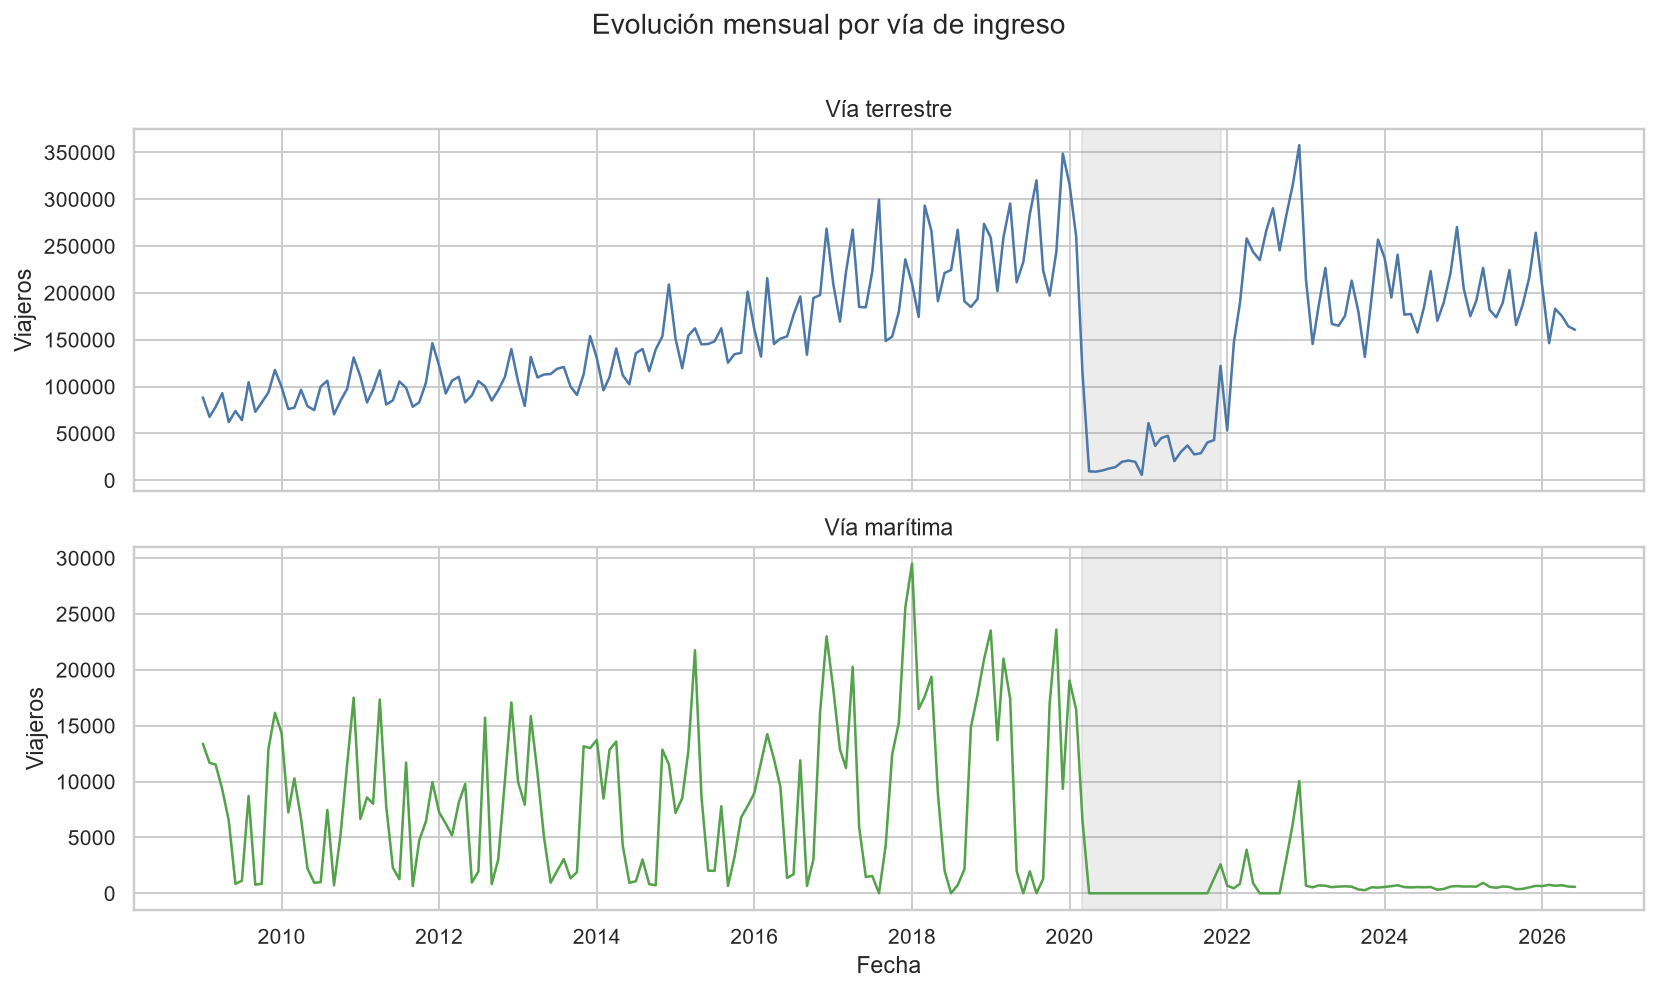

### Comparación de modelos y métricas

,region,modelo,configuracion,MAE,RMSE,AIC,BIC,seleccion_final
0,Vía marítima,Holt-Winters,,902.627077,1685.061540,2506.030081,2556.867435,True
1,Vía marítima,ARIMA/SARIMA seleccionado,"ARIMA(1, 1, 1)",857.125008,1731.011817,616.773730,625.683170,False
2,Vía marítima,Suavizamiento exponencial simple,,858.365064,1731.929681,2569.252233,2575.233099,False
3,Vía marítima,Seasonal naïve,,858.365079,1731.929693,NaN,NaN,False
4,Vía marítima,Prophet,,960.453269,1822.734915,NaN,NaN,False
5,Vía terrestre,ARIMA/SARIMA seleccionado,"SARIMA(0, 0, 1)x(0, 1, 1, 12)",87236.857522,95326.844536,222.616868,231.004240,False
6,Vía terrestre,Suavizamiento exponencial simple,,140734.645704,156651.759364,3120.973922,3126.954787,False
7,Vía terrestre,Holt-Winters,,143689.645008,158598.130920,3072.781600,3123.618954,True
8,Vía terrestre,Seasonal naïve,,160013.007381,176652.992181,NaN,NaN,False
9,Vía terrestre,Prophet,,174322.576545,189011.532668,NaN,NaN,False


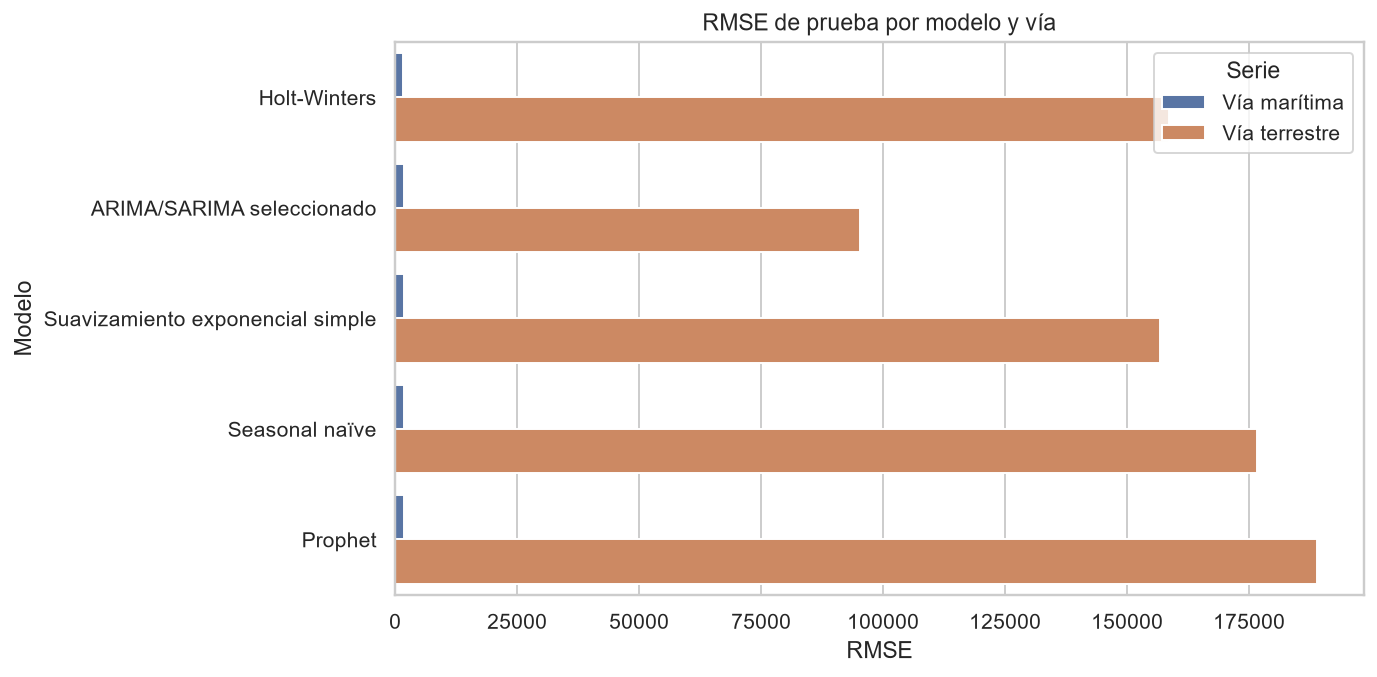

### Diagnóstico de residuos

,region,modelo,media_residuos,desviacion_residuos,ljung_box_p_12,jarque_bera_p,seleccion_final
0,Vía marítima,ARIMA/SARIMA seleccionado,-0.228270,2.115496,7.598510e-05,1.042948e-53,False
1,Vía marítima,Holt-Winters,-91.779884,4498.363952,2.011515e-03,2.297456e-01,True
2,Vía marítima,Prophet,95.182124,4031.773184,4.152820e-06,1.031783e-02,False
3,Vía marítima,Seasonal naïve,-694.103704,5891.303205,5.609741e-09,3.631948e-13,False
4,Vía marítima,Suavizamiento exponencial simple,-109.620031,6177.087724,6.260322e-18,7.889273e-01,False
5,Vía terrestre,ARIMA/SARIMA seleccionado,0.086090,0.560118,1.786859e-31,2.678389e-145,False
6,Vía terrestre,Holt-Winters,-407.367706,30924.915695,1.098394e-01,3.765964e-117,True
7,Vía terrestre,Prophet,39.719984,45185.259574,5.094921e-50,2.997495e-12,False
8,Vía terrestre,Seasonal naïve,-5445.953582,79060.283538,4.123067e-70,1.011093e-79,False
9,Vía terrestre,Suavizamiento exponencial simple,-428.551120,40348.452022,1.343562e-15,1.425585e-17,False


### Modelos seleccionados

,region,modelo,configuracion,MAE,RMSE,ljung_box_p_12
3,Vía terrestre,Holt-Winters,,143689.645008,158598.13092,0.109839
8,Vía marítima,Holt-Winters,,902.627077,1685.06154,0.002012


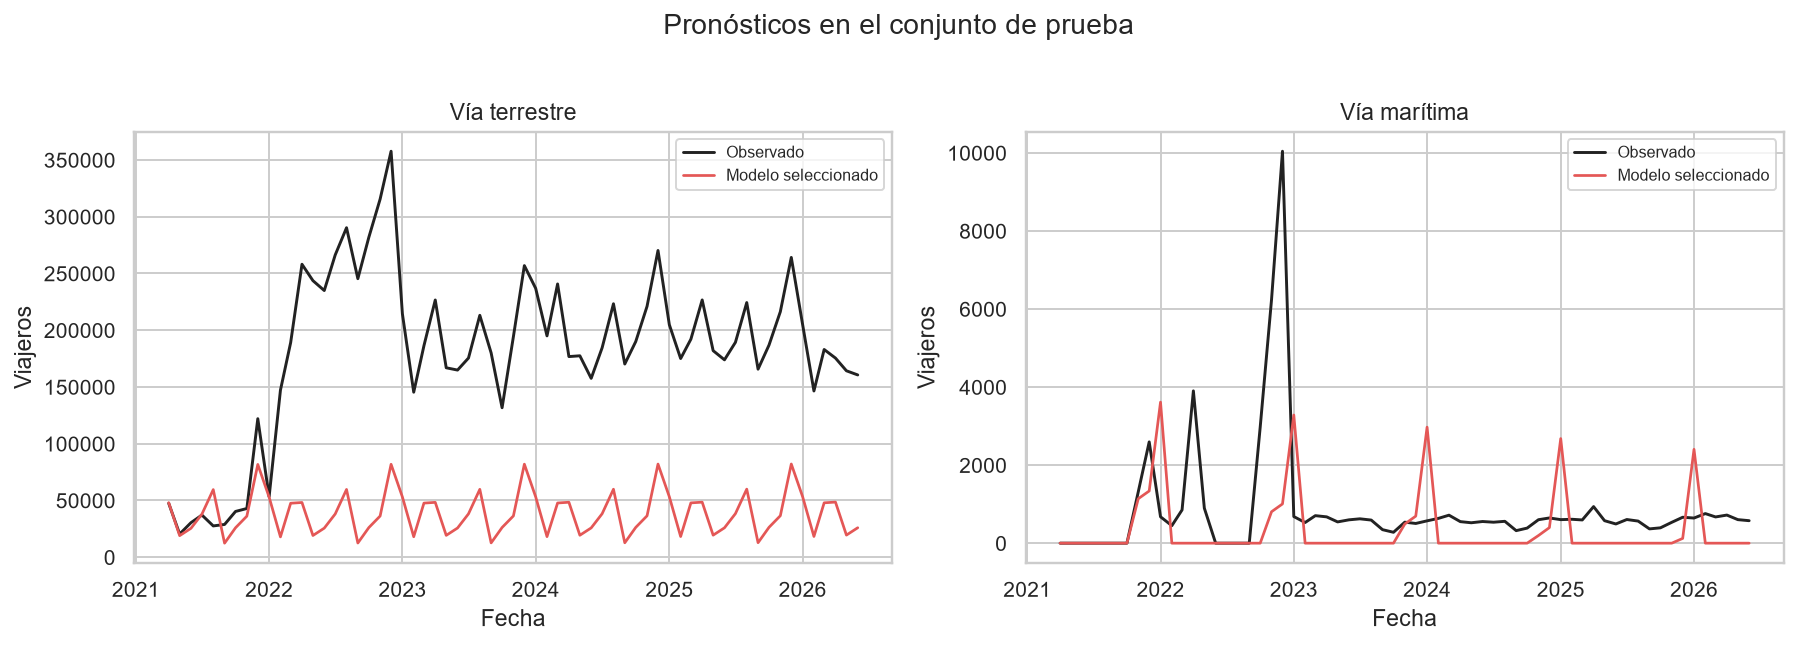

In [18]:
# Las funciones de diagnóstico y evaluación se definieron en la sección de Región dos.
globals()['OUT'] = ROOT / 'resultados_laboratorio_1' / 'vias_terrestre_maritima'
globals()['FIG'] = globals()['OUT'] / 'figuras'
globals()['OUT'].mkdir(parents=True, exist_ok=True)
globals()['FIG'].mkdir(parents=True, exist_ok=True)

series_persona_2 = series_vias[['Terrestre', 'Marítima']].reindex(total.index).fillna(0).astype(float)
series_persona_2.columns = ['Vía terrestre', 'Vía marítima']
series_persona_2.index.name = 'fecha'
indice_esperado = pd.date_range(series_persona_2.index.min(), series_persona_2.index.max(), freq='MS')
assert series_persona_2.index.equals(indice_esperado)
assert not series_persona_2.isna().any().any()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, nombre, color in zip(axes, series_persona_2.columns, ['#4C78A8', '#54A24B']):
    ax.plot(series_persona_2.index, series_persona_2[nombre], color=color, linewidth=1.3)
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='grey', alpha=.15)
    ax.set(title=nombre, ylabel='Viajeros')
axes[-1].set_xlabel('Fecha')
fig.suptitle('Evolución mensual por vía de ingreso', y=1.01)
fig.tight_layout()
plt.show()

resumen_p2, adf_p2, d_p2 = _diagnostico_series(series_persona_2)
impacto_p2 = _impacto_pandemia(series_persona_2)
modelos_p2, arimas_p2, predicciones_p2, residuos_p2 = _evaluar_modelos(series_persona_2, d_p2)
componentes_p2 = _fuerza_componentes(series_persona_2)
selecciones_p2 = modelos_p2.loc[modelos_p2['seleccion_final']].copy()

tabla_metricas_p2 = modelos_p2[['region', 'modelo', 'configuracion', 'MAE', 'RMSE', 'AIC', 'BIC', 'seleccion_final']].sort_values(['region', 'RMSE'])
tabla_residuos_p2 = modelos_p2[['region', 'modelo', 'media_residuos', 'desviacion_residuos', 'ljung_box_p_12', 'jarque_bera_p', 'seleccion_final']].sort_values(['region', 'modelo'])
display(Markdown('### Comparación de modelos y métricas'))
display(tabla_metricas_p2.reset_index(drop=True))
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tabla_metricas_p2, x='RMSE', y='modelo', hue='region', ax=ax)
ax.set(title='RMSE de prueba por modelo y vía', xlabel='RMSE', ylabel='Modelo')
ax.legend(title='Serie')
fig.tight_layout()
plt.show()

display(Markdown('### Diagnóstico de residuos'))
display(tabla_residuos_p2.reset_index(drop=True))
display(Markdown('### Modelos seleccionados'))
display(selecciones_p2[['region', 'modelo', 'configuracion', 'MAE', 'RMSE', 'ljung_box_p_12']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, nombre in zip(axes, series_persona_2.columns):
    prueba = predicciones_p2.loc[predicciones_p2['region'].eq(nombre)]
    mejor = selecciones_p2.loc[selecciones_p2['region'].eq(nombre), 'modelo'].iloc[0]
    ax.plot(prueba['fecha'], prueba['real'], label='Observado', color='#222222', linewidth=1.5)
    ax.plot(prueba['fecha'], prueba[mejor], label='Modelo seleccionado', color='#E45756', linewidth=1.4)
    ax.set(title=nombre, xlabel='Fecha', ylabel='Viajeros')
    ax.legend(fontsize=8)
fig.suptitle('Pronósticos en el conjunto de prueba', y=1.02)
fig.tight_layout()
plt.show()


La vía terrestre se selecciona con Holt-Winters y presenta residuos sin autocorrelación significativa. Para la vía marítima Holt-Winters tiene el menor RMSE, aunque ningún método supera la prueba de Ljung-Box al 5%; por ello sus resultados deben interpretarse con cautela.


### 4.3 Tres regiones principales de `Región dos`

Las tres series regionales se analizan sobre `log1p(Turista +
Excursionista)`, conservando los ceros observados durante la pandemia.


In [19]:
OUT = OUT_BASE / "regiones"
FIG = OUT / "figuras"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

resumen_regiones, adf_regiones, d_regiones = _diagnostico_series(
    series_regiones_comparables
)
impacto_regiones = _impacto_pandemia(series_regiones_comparables)
(
    modelos_regiones,
    arimas_regiones,
    predicciones_regiones,
    residuos_regiones,
) = _evaluar_modelos(series_regiones_comparables, d_regiones)
componentes_regiones = _fuerza_componentes(series_regiones_comparables)
informe_regiones = _informe(
    datos_regiones,
    top3_regiones,
    resumen_regiones,
    adf_regiones,
    impacto_regiones,
    modelos_regiones,
    componentes_regiones,
)
_validar(
    top3_regiones,
    series_regiones_comparables,
    modelos_regiones,
    predicciones_regiones,
)

resultados_regiones = {
    "top3": top3_regiones,
    "series_todas": series_regiones_todas,
    "series_comparables": series_regiones_comparables,
    "ranking_paises": ranking_paises_regiones,
    "tipo_anual": composicion_tipo_viajero,
    "resumen": resumen_regiones,
    "estacionariedad": adf_regiones,
    "impacto_pandemia": impacto_regiones,
    "modelos": modelos_regiones,
    "candidatos_arima": arimas_regiones,
    "predicciones": predicciones_regiones,
    "residuos": residuos_regiones,
    "componentes": componentes_regiones,
    "informe": informe_regiones,
}

display(Markdown("#### Impacto de la pandemia"))
display(impacto_regiones)
display(Markdown("#### Comparación de modelos por región"))
display(
    modelos_regiones.sort_values(["region", "RMSE"]).reset_index(drop=True)
)


#### Impacto de la pandemia

,region,visitantes_2019,visitantes_2020,cambio_2019_2020,visitantes_2021,cambio_2019_2021,visitantes_2022,nivel_2022_vs_2019,visitantes_2025,nivel_2025_vs_2019,primer_año_recupera_2019
0,América Del Centro,3.247683e+06,830397.067967,-0.744311,754938.378976,-0.767546,2449577.6,0.754254,2.143694e+06,0.660069,NaN
1,América Del Norte,6.025570e+05,155795.278443,-0.741443,264889.000000,-0.560392,533316.0,0.885088,8.393801e+05,1.393030,2023.0
2,Europa,1.412380e+05,39787.158812,-0.718297,36379.503414,-0.742424,124741.0,0.883197,1.762619e+05,1.247978,2023.0


#### Comparación de modelos por región

,region,modelo,inicio_train,fin_train,inicio_prueba,fin_prueba,n_train,n_prueba,MAE,RMSE,...,BIC,escala_AIC_BIC,configuracion,escala_residuos,media_residuos,desviacion_residuos,ljung_box_p_12,jarque_bera_p,mejor_por_rmse,seleccion_final
0,América Del Centro,Holt-Winters,2009-01,2021-03,2021-04,2026-06,147,63,108070.439239,117653.972657,...,3100.611271,original,,original,-485.673349,28595.430022,7.821108e-01,6.699435e-170,True,True
1,América Del Centro,ARIMA/SARIMA seleccionado,2009-01,2021-03,2021-04,2026-06,147,63,106457.757771,118471.343015,...,93.794581,log1p,"ARIMA(1, 1, 1)",log1p,-0.008483,0.333362,1.169203e-01,0.000000e+00,False,False
2,América Del Centro,Suavizamiento exponencial simple,2009-01,2021-03,2021-04,2026-06,147,63,109866.631377,121961.428939,...,3120.840476,original,,original,-400.750739,39518.190052,1.643422e-14,1.102391e-09,False,False
3,América Del Centro,Seasonal naïve,2009-01,2021-03,2021-04,2026-06,147,63,134400.175117,144899.302913,...,NaN,no aplica,,original,-6979.185384,78651.665225,2.026930e-79,1.326019e-72,False,False
4,América Del Centro,Prophet,2009-01,2021-03,2021-04,2026-06,147,63,150541.372718,163831.533300,...,NaN,no disponible,,original,-65.683269,44492.648412,1.463466e-54,6.900316e-09,False,False
5,América Del Norte,ARIMA/SARIMA seleccionado,2009-01,2021-03,2021-04,2026-06,147,63,32062.069054,36530.651502,...,438.717483,log1p,"ARIMA(1, 0, 1)",log1p,-0.011104,1.110725,9.987107e-03,0.000000e+00,True,False
6,América Del Norte,Holt-Winters,2009-01,2021-03,2021-04,2026-06,147,63,40351.065503,43885.046005,...,2626.883917,original,,original,-131.275256,5707.655524,4.684984e-01,3.066625e-231,False,True
7,América Del Norte,Suavizamiento exponencial simple,2009-01,2021-03,2021-04,2026-06,147,63,39602.711020,44299.538191,...,2741.081446,original,,original,-305.927570,10855.977280,1.880382e-21,2.240095e-01,False,False
8,América Del Norte,Seasonal naïve,2009-01,2021-03,2021-04,2026-06,147,63,49974.107806,53533.367253,...,NaN,no aplica,,original,-2510.384454,14305.602024,1.460424e-71,1.129132e-96,False,False
9,América Del Norte,Prophet,2009-01,2021-03,2021-04,2026-06,147,63,53928.303911,58681.167798,...,NaN,no disponible,,original,7.942879,8133.286803,1.690170e-44,5.650808e-19,False,False


In [20]:
display(Markdown(resultados_regiones["informe"]))


# Análisis de países, regiones y tipo de viajero

## Criterio y alcance

El Top 3 se calculó con la suma de `Viajero` para **todo el período enero 2009–junio 2026**. Se excluyó únicamente la etiqueta no semántica `0` (821 personas), sin efecto sobre las tres primeras posiciones. Para modelar visitas se usó **Turista + Excursionista**, porque la hoja `Notas` indica que la categoría `Viajero` no es un visitante y presenta un quiebre metodológico en 2023.

## Top 3 de Región dos

| Posición | Región | Acumulado (todas las categorías) | Participación |
|---:|---|---:|---:|
| 1 | América Del Centro | 37,406,535 | 71.5% |
| 2 | América Del Norte | 9,383,035 | 17.9% |
| 3 | Europa | 2,222,621 | 4.3% |

## Tipo de viajero y quiebre de 2023

La categoría `Viajero` cambió -68.8% entre 2022 y 2023, mientras `Turista + Excursionista` cambió -9.6%. Por tanto, sumar todas las categorías introduciría personas que no son visitantes y amplificaría un cambio de medición. Los países pequeños tampoco son plenamente comparables desde 2023 porque pasan a agrupaciones de mercado; por eso las series finales se agregan por `Región dos`.

## Diagnóstico y comparación por región

Todas las series son mensuales, tienen 210 observaciones y cubren 2009-01 a 2026-06. Se aplicó `log1p` para estabilizar varianza y admitir los ceros de la pandemia. La ADF, ACF/PACF, la descomposición y las tablas exportadas sustentan la diferenciación propuesta. Los AIC/BIC se comparan solo entre modelos en la misma escala. La selección final minimiza el RMSE de prueba entre modelos con Ljung–Box p≥0.05; si ninguno cumpliera ese criterio, usaría el menor RMSE con una advertencia.

| Región | ADF p (log1p) | d propuesto | Fuerza estacional | Caída 2020 vs 2019 | Selección final | MAE | RMSE | Ljung–Box p |
|---|---:|---:|---:|---:|---|---:|---:|---:|
| América Del Centro | 0.0544 | 1 | 0.263 | -74.4% | Holt-Winters | 108,070 | 117,654 | 0.7821 |
| América Del Norte | 0.0393 | 0 | 0.083 | -74.1% | Holt-Winters | 40,351 | 43,885 | 0.4685 |
| Europa | 0.0052 | 0 | 0.211 | -71.8% | ARIMA/SARIMA seleccionado (ARIMA(1, 0, 1)) | 6,420 | 7,824 | 0.0643 |

## Análisis detallado de la región líder

**América Del Centro** concentra 71.5% del acumulado regional válido. La serie muestra tendencia, un patrón anual (fuerza estacional 0.263) y un quiebre excepcional desde marzo de 2020. En 2020 cayó -74.4% respecto de 2019; en 2022 alcanzó 75.4% del nivel de 2019. La ACF/PACF y ADF se reportan en las figuras y CSV; se compararon `d=0` y `d=1`, además de diferenciación estacional de período 12; el candidato ARIMA elegido fue `ARIMA(1, 1, 1)`. La transformación elegida es `log1p` y la selección final combina desempeño fuera de muestra con residuos sin autocorrelación significativa al 5%.

## Efecto de la pandemia

La partición solicitada (70%/30%) deja el entrenamiento hasta 2021-03 y la prueba desde 2021-04. Esto convierte el backtest en una prueba de estrés: los modelos deben extrapolar desde el piso pandémico hacia una recuperación y atravesar el cambio de fuente de 2023. Las métricas son válidas para comparar bajo ese escenario, pero no equivalen a una validación operativa en condiciones estables.

| Región | 2020 vs 2019 | 2021 vs 2019 | 2022/2019 | 2025/2019 | Primer año ≥ 2019 |
|---|---:|---:|---:|---:|---:|
| América Del Centro | -74.4% | -76.8% | 75.4% | 66.0% | No hasta 2025 |
| América Del Norte | -74.1% | -56.0% | 88.5% | 139.3% | 2023 |
| Europa | -71.8% | -74.2% | 88.3% | 124.8% | 2023 |

## Recomendaciones para INGUAT

1. Planificar capacidad y campañas por región, no con una única curva agregada: volumen, estacionalidad y velocidad de recuperación son distintos en las tres regiones.
2. Mantener `Turista + Excursionista` como indicador comparable de visitas. Reportar `Viajero` por separado y marcar visualmente el quiebre de 2023; los cruceristas requieren una fuente portuaria externa desde ese año.
3. Usar el modelo ganador por RMSE como referencia, pero reentrenarlo mensualmente y complementarlo con validación de origen rodante. La división 70/30 queda dominada por pandemia, recuperación y cambio de fuente.
4. Incorporar intervenciones explícitas para cierres pandémicos y cambios metodológicos antes de emplear los pronósticos para presupuesto o dotación de personal.
5. Conservar las agregaciones `Región dos` para continuidad histórica; desde 2023 varios países pequeños se publican como agrupaciones y no deben interpretarse como series nacionales continuas.

## Archivos de evidencia

Las tablas, predicciones, residuos y figuras se encuentran en `resultados_laboratorio_1/regiones/`. El notebook valida explícitamente si el Top 3 no tiene tres regiones, existen huecos mensuales o falta alguno de los cinco enfoques de modelado requeridos.


La descomposición y ACF/PACF se generaron para cada región. A continuación se
muestra la evidencia de la región líder y la comparación de pronósticos.

![Descomposición de América Del Centro](resultados_laboratorio_1/regiones/figuras/12_descomposicion_america_del_centro.png)

![ACF y PACF de América Del Centro](resultados_laboratorio_1/regiones/figuras/13_acf_pacf_america_del_centro.png)

La prueba 70/30 incluye recuperación y cambio de fuente, por lo que funciona
como una prueba de estrés.

![Pronósticos de América Del Centro](resultados_laboratorio_1/regiones/figuras/15_pronosticos_america_del_centro.png)

![Comparación de RMSE](resultados_laboratorio_1/regiones/figuras/17_comparacion_rmse_modelos.png)


## 5. Análisis comparativo y recomendaciones

La fuerza estacional proviene de la descomposición; el crecimiento se calcula
comparando los promedios de los primeros y últimos 12 meses; la volatilidad se
mide mediante el coeficiente de variación; y la afectación pandémica mediante
el peor cambio de 2020 o 2021 respecto de 2019.


### 5.1 Comparación de las regiones

,region,fuerza_estacional,fuerza_tendencia,coeficiente_variacion,cambio_2019_2020,cambio_2019_2021,crecimiento_anualizado,peor_caida_pandemia
0,América Del Centro,0.263080,0.828286,0.419428,-0.744311,-0.767546,0.029050,-0.767546
1,América Del Norte,0.083479,0.625124,0.409902,-0.741443,-0.560392,0.046183,-0.741443
2,Europa,0.210742,0.722533,0.430040,-0.718297,-0.742424,0.030066,-0.742424


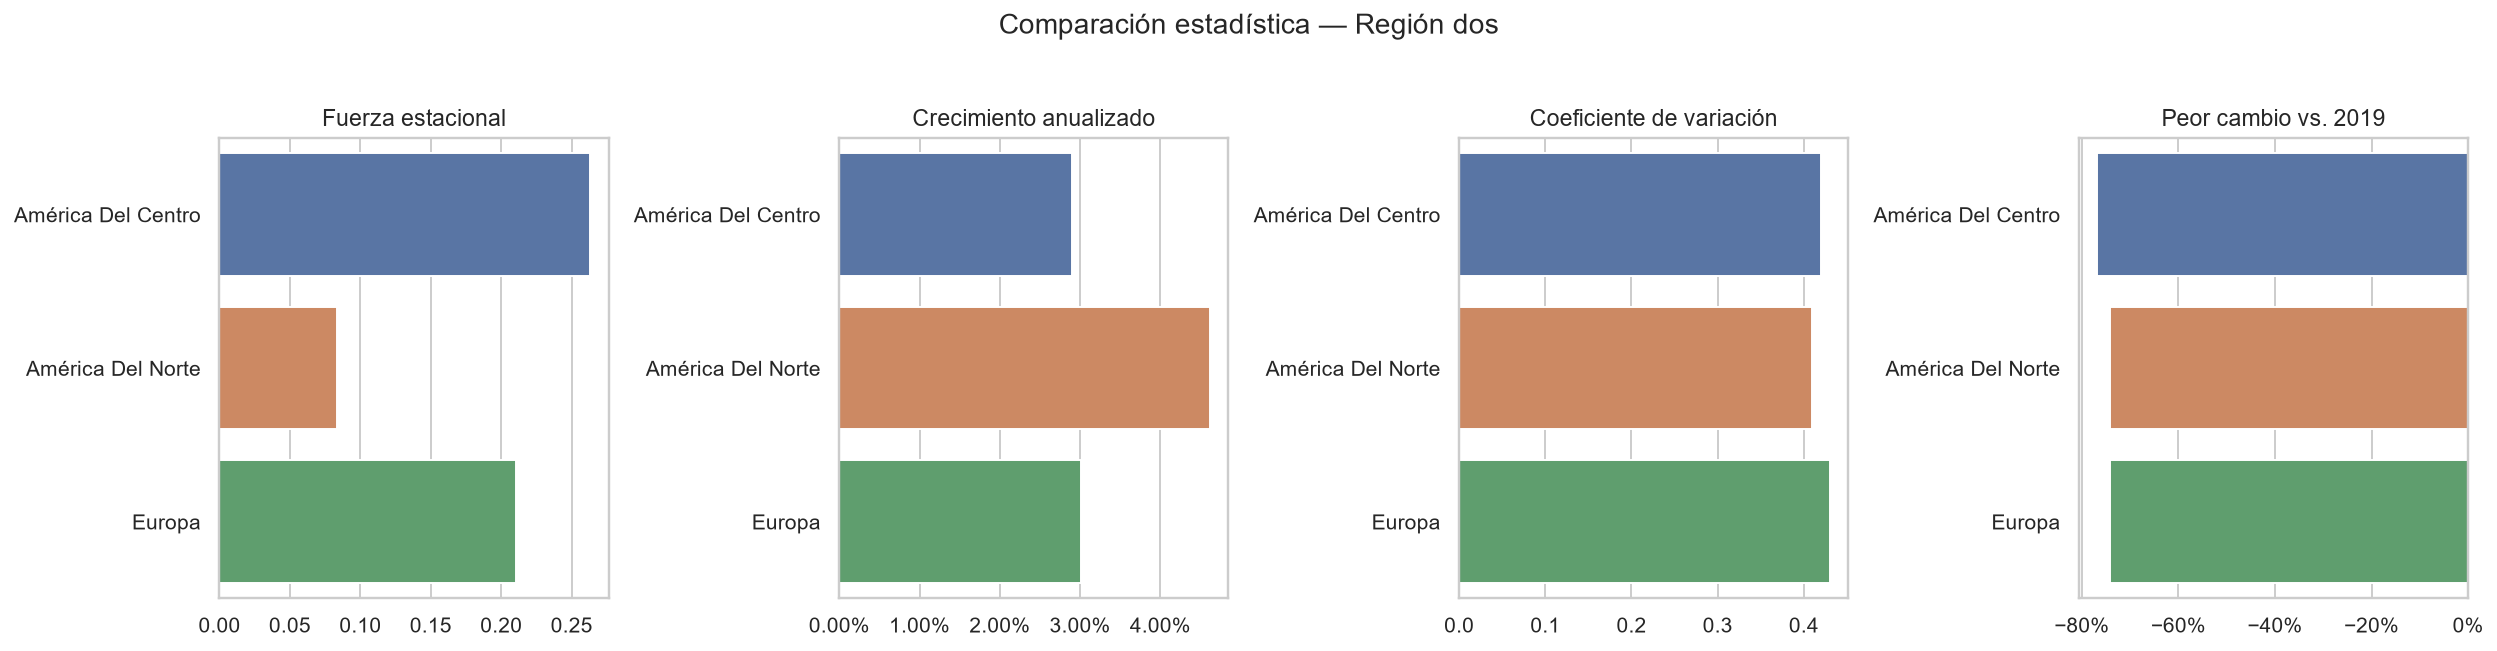

### 5.2 Comparación de las vías de ingreso

,region,fuerza_estacional,fuerza_tendencia,coeficiente_variacion,cambio_2019_2020,cambio_2019_2021,crecimiento_anualizado,peor_caida_pandemia
0,Vía aérea,0.159083,0.694256,0.305441,-0.722912,-0.511999,0.017783,-0.722912
1,Vía terrestre,0.176929,0.828589,0.492537,-0.735733,-0.824552,0.051282,-0.824552
2,Vía marítima,0.355537,0.689743,1.146541,-0.678933,-0.970120,-0.144740,-0.970120


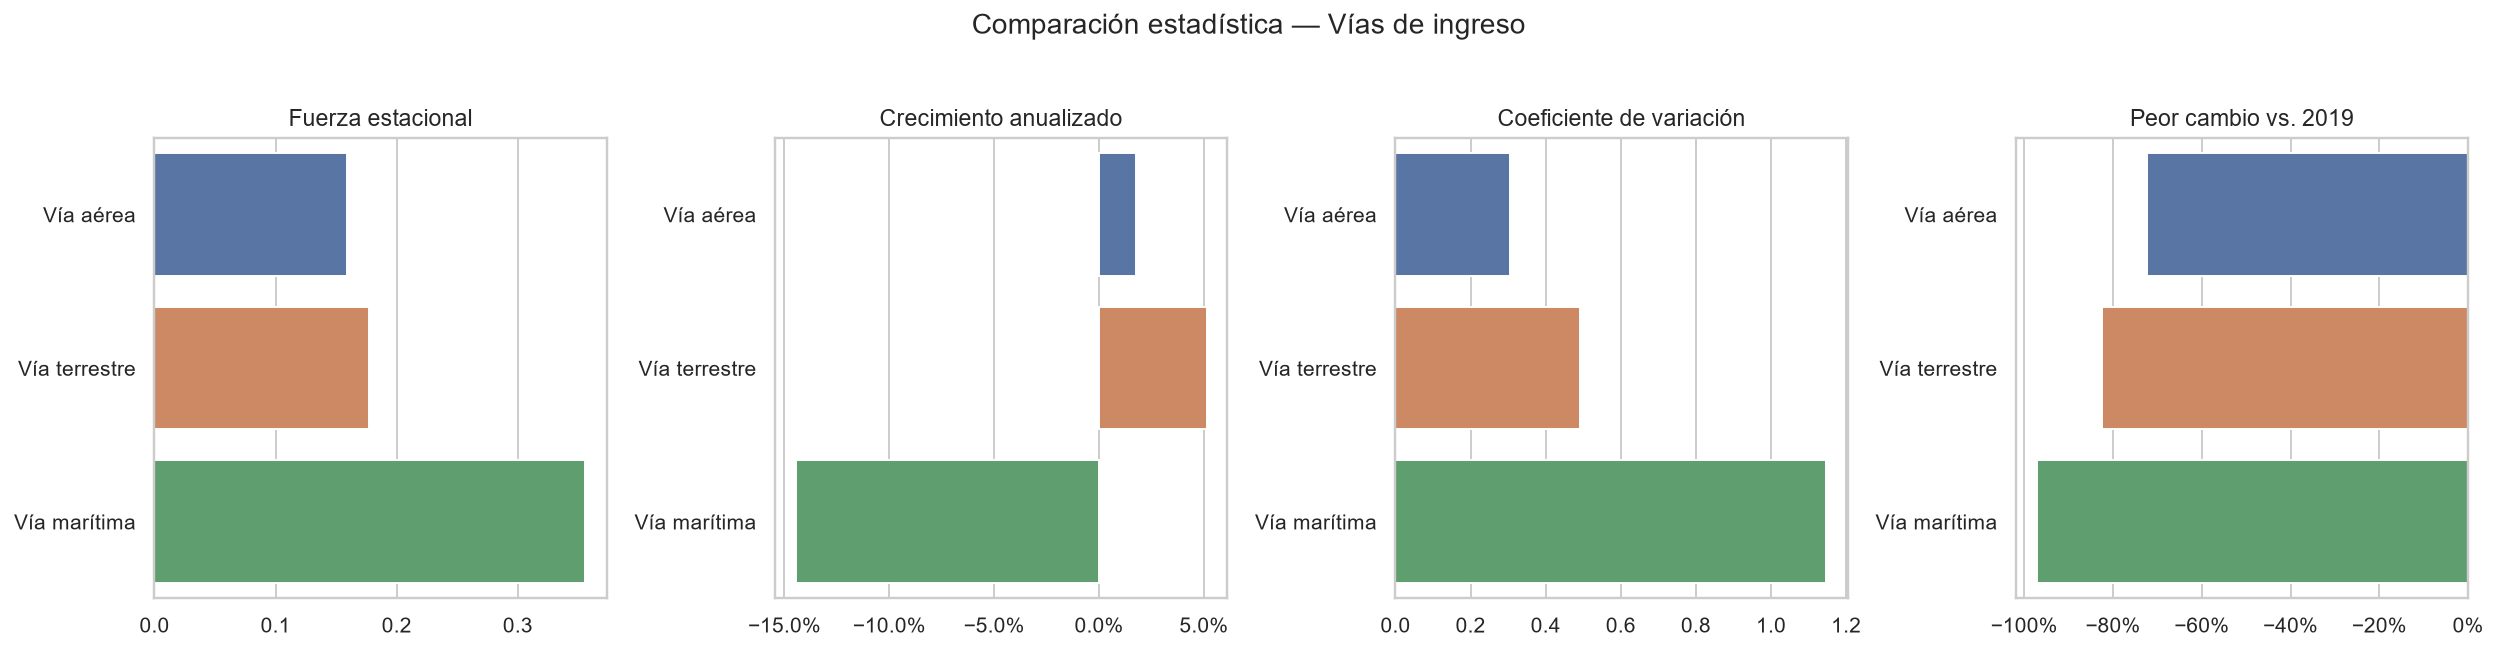


### 5.3 Respuestas comparativas

**Regiones geográficas**

- Mayor estacionalidad: **América Del Centro**, con fuerza estacional de 0.263.
- Mayor tendencia de crecimiento de largo plazo: **América Del Norte**, con crecimiento anualizado de 4.6%, calculado con los promedios de los primeros y últimos 12 meses.
- Mayor volatilidad relativa: **Europa**, con coeficiente de variación de 0.430.
- Mayor afectación pandémica: **América Del Centro**, cuyo peor cambio anual frente a 2019 fue -76.8%.

**Vías de ingreso**

- Mayor estacionalidad: **Vía marítima**, con fuerza estacional de 0.356.
- Mayor tendencia de crecimiento de largo plazo: **Vía terrestre**, con crecimiento anualizado de 5.1%.
- Mayor volatilidad relativa: **Vía marítima**, con coeficiente de variación de 1.147.
- Mayor afectación pandémica: **Vía marítima**, cuyo peor cambio anual frente a 2019 fue -97.0%.

### 5.4 Hallazgos útiles para INGUAT

1. La planificación debe diferenciar regiones y vías: sus volúmenes, estacionalidad, volatilidad y recuperación no son intercambiables.
2. Para comparaciones regionales históricas se debe mantener `Turista + Excursionista` y reportar por separado el quiebre metodológico de `Viajero` en 2023.
3. Las series con mayor volatilidad o con recuperación incompleta necesitan escenarios de capacidad y no únicamente un pronóstico puntual.
4. Los modelos deben reentrenarse periódicamente y validarse con origen rodante, porque la partición 70/30 contiene pandemia, recuperación y cambio metodológico.
5. AIC y BIC se interpretan solamente entre candidatos ARIMA/SARIMA ajustados sobre la misma escala; la selección general se apoya en MAE, RMSE y residuos.


In [21]:
def tasa_crecimiento_anualizada(serie: pd.Series) -> float:
    """Compara el promedio de los primeros y últimos 12 meses."""
    primera_ventana = float(serie.iloc[:12].mean())
    ultima_ventana = float(serie.iloc[-12:].mean())
    años = (len(serie) - 12) / 12
    if primera_ventana <= 0 or ultima_ventana < 0 or años <= 0:
        return np.nan
    return (ultima_ventana / primera_ventana) ** (1 / años) - 1


def tabla_comparativa_categoria(
    series: pd.DataFrame,
    resumen: pd.DataFrame,
    componentes: pd.DataFrame,
    impacto: pd.DataFrame,
) -> pd.DataFrame:
    resultado = (
        componentes[["region", "fuerza_estacional", "fuerza_tendencia"]]
        .merge(
            resumen[["region", "coeficiente_variacion"]],
            on="region",
            how="inner",
        )
        .merge(
            impacto[
                ["region", "cambio_2019_2020", "cambio_2019_2021"]
            ],
            on="region",
            how="inner",
        )
    )
    crecimiento = {
        nombre: tasa_crecimiento_anualizada(series[nombre])
        for nombre in series.columns
    }
    resultado["crecimiento_anualizado"] = resultado["region"].map(
        crecimiento
    )
    resultado["peor_caida_pandemia"] = resultado[
        ["cambio_2019_2020", "cambio_2019_2021"]
    ].min(axis=1)
    return resultado


series_vias_completas = pd.DataFrame(
    {
        "Vía aérea": aerea_final,
        "Vía terrestre": series_persona_2["Vía terrestre"],
        "Vía marítima": series_persona_2["Vía marítima"],
    }
)
resumen_vias = pd.concat(
    [
        resumen_p1.loc[resumen_p1["region"].eq("Vía aérea")],
        resumen_p2,
    ],
    ignore_index=True,
)
componentes_vias = pd.concat(
    [
        componentes_p1.loc[componentes_p1["region"].eq("Vía aérea")],
        componentes_p2,
    ],
    ignore_index=True,
)
impacto_vias = pd.concat(
    [
        impacto_p1.loc[impacto_p1["region"].eq("Vía aérea")],
        impacto_p2,
    ],
    ignore_index=True,
)

comparacion_regiones = tabla_comparativa_categoria(
    series_regiones_comparables,
    resumen_regiones,
    componentes_regiones,
    impacto_regiones,
)
comparacion_vias = tabla_comparativa_categoria(
    series_vias_completas,
    resumen_vias,
    componentes_vias,
    impacto_vias,
)

OUT_COMPARACION = OUT_BASE / "comparacion_final"
OUT_COMPARACION.mkdir(parents=True, exist_ok=True)
comparacion_regiones.to_csv(
    OUT_COMPARACION / "comparacion_regiones.csv",
    index=False,
    encoding="utf-8-sig",
)
comparacion_vias.to_csv(
    OUT_COMPARACION / "comparacion_vias.csv",
    index=False,
    encoding="utf-8-sig",
)


def graficar_comparacion(tabla: pd.DataFrame, categoria: str, archivo: str) -> None:
    indicadores = [
        ("fuerza_estacional", "Fuerza estacional"),
        ("crecimiento_anualizado", "Crecimiento anualizado"),
        ("coeficiente_variacion", "Coeficiente de variación"),
        ("peor_caida_pandemia", "Peor cambio vs. 2019"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, (columna, titulo) in zip(axes, indicadores):
        sns.barplot(
            data=tabla,
            x=columna,
            y="region",
            hue="region",
            legend=False,
            ax=ax,
        )
        ax.set(title=titulo, xlabel="", ylabel="")
        if columna in {"crecimiento_anualizado", "peor_caida_pandemia"}:
            ax.xaxis.set_major_formatter(PercentFormatter(1))
    fig.suptitle(f"Comparación estadística — {categoria}", y=1.03)
    fig.tight_layout()
    fig.savefig(OUT_COMPARACION / archivo, bbox_inches="tight")
    plt.show()


display(Markdown("### 5.1 Comparación de las regiones"))
display(comparacion_regiones)
graficar_comparacion(
    comparacion_regiones,
    "Región dos",
    "comparacion_regiones.png",
)

display(Markdown("### 5.2 Comparación de las vías de ingreso"))
display(comparacion_vias)
graficar_comparacion(
    comparacion_vias,
    "Vías de ingreso",
    "comparacion_vias.png",
)


def fila_max(tabla: pd.DataFrame, columna: str) -> pd.Series:
    return tabla.loc[tabla[columna].idxmax()]


def fila_min(tabla: pd.DataFrame, columna: str) -> pd.Series:
    return tabla.loc[tabla[columna].idxmin()]


est_reg = fila_max(comparacion_regiones, "fuerza_estacional")
crec_reg = fila_max(comparacion_regiones, "crecimiento_anualizado")
vol_reg = fila_max(comparacion_regiones, "coeficiente_variacion")
pand_reg = fila_min(comparacion_regiones, "peor_caida_pandemia")

est_via = fila_max(comparacion_vias, "fuerza_estacional")
crec_via = fila_max(comparacion_vias, "crecimiento_anualizado")
vol_via = fila_max(comparacion_vias, "coeficiente_variacion")
pand_via = fila_min(comparacion_vias, "peor_caida_pandemia")

conclusiones_comparativas = f"""
### 5.3 Respuestas comparativas

**Regiones geográficas**

- Mayor estacionalidad: **{est_reg['region']}**, con fuerza estacional de {est_reg['fuerza_estacional']:.3f}.
- Mayor tendencia de crecimiento de largo plazo: **{crec_reg['region']}**, con crecimiento anualizado de {crec_reg['crecimiento_anualizado']:.1%}, calculado con los promedios de los primeros y últimos 12 meses.
- Mayor volatilidad relativa: **{vol_reg['region']}**, con coeficiente de variación de {vol_reg['coeficiente_variacion']:.3f}.
- Mayor afectación pandémica: **{pand_reg['region']}**, cuyo peor cambio anual frente a 2019 fue {pand_reg['peor_caida_pandemia']:.1%}.

**Vías de ingreso**

- Mayor estacionalidad: **{est_via['region']}**, con fuerza estacional de {est_via['fuerza_estacional']:.3f}.
- Mayor tendencia de crecimiento de largo plazo: **{crec_via['region']}**, con crecimiento anualizado de {crec_via['crecimiento_anualizado']:.1%}.
- Mayor volatilidad relativa: **{vol_via['region']}**, con coeficiente de variación de {vol_via['coeficiente_variacion']:.3f}.
- Mayor afectación pandémica: **{pand_via['region']}**, cuyo peor cambio anual frente a 2019 fue {pand_via['peor_caida_pandemia']:.1%}.

### 5.4 Hallazgos útiles para INGUAT

1. La planificación debe diferenciar regiones y vías: sus volúmenes, estacionalidad, volatilidad y recuperación no son intercambiables.
2. Para comparaciones regionales históricas se debe mantener `Turista + Excursionista` y reportar por separado el quiebre metodológico de `Viajero` en 2023.
3. Las series con mayor volatilidad o con recuperación incompleta necesitan escenarios de capacidad y no únicamente un pronóstico puntual.
4. Los modelos deben reentrenarse periódicamente y validarse con origen rodante, porque la partición 70/30 contiene pandemia, recuperación y cambio metodológico.
5. AIC y BIC se interpretan solamente entre candidatos ARIMA/SARIMA ajustados sobre la misma escala; la selección general se apoya en MAE, RMSE y residuos.
"""
display(Markdown(conclusiones_comparativas))
